# Lab 03 - Local Features and Panorama Stitching

**Topics:** Harris corners, SIFT descriptors, feature matching, feather blending, and clipping  
**Suggested duration:** 60 minutes

## Learning outcomes

By the end of this lab, you should be able to:

1. implement Harris corner detection with non-maximum suppression;
2. extract and match 128-dimensional SIFT descriptors; and
3. combine 10 real overlapping photographs into a clean panorama.

The three tasks are **(a) Harris corners**, **(b) SIFT descriptors**, and **(c) panorama construction**.

## 0. Setup - 5 minutes

Place `IMG_01.jpg` through `IMG_10.jpg` in `ntu_wave/`. The photographs are ordered from right to left.

Real panorama photographs are produced mainly by camera rotation. A long chain of unconstrained planar homographies can therefore stretch badly. The supplied setup:

1. resizes the photographs for fast execution;
2. projects each photograph onto a cylinder; and
3. keeps a validity mask for clipping the black border later.

In [ ]:
! gdown https://drive.google.com/drive/folders/1bAH88ugl6CziGVKe2Ip9sIRrtFIwJ_Dd?usp=drive_link --folder

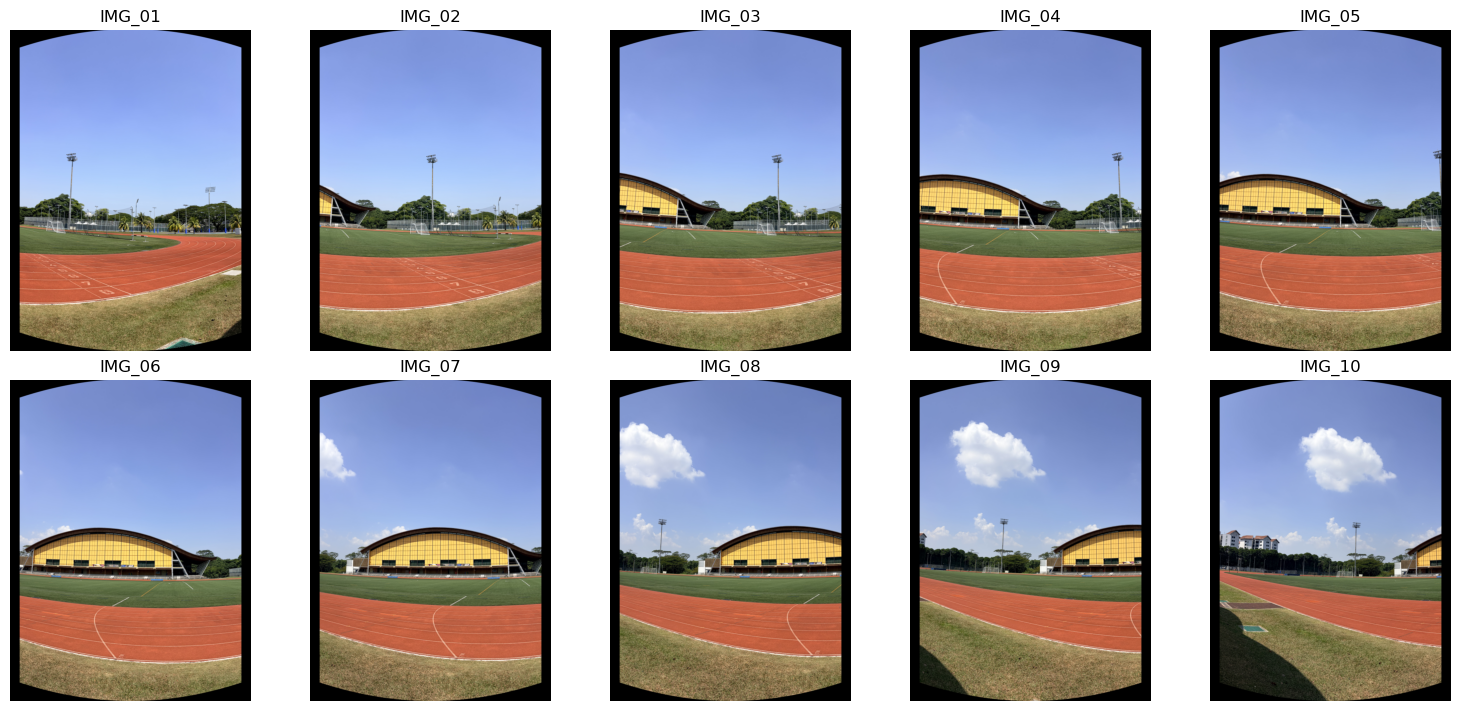

Loaded 10 images; working shape: (900, 675, 3)


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

IMAGE_DIR = Path("ntu_wave")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

image_paths = sorted(IMAGE_DIR.glob("IMG_*.jpg"))
assert len(image_paths) == 10, f"Expected 10 images, found {len(image_paths)}"

def resize_to_height(rgb, height=900):
    scale = height / rgb.shape[0]
    return cv2.resize(rgb, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

def cylindrical_warp(rgb, focal_length=None):
    h, w = rgb.shape[:2]
    f = focal_length or 0.95 * w
    yy, xx = np.indices((h, w), dtype=np.float32)
    theta = (xx - w / 2) / f
    cylinder_y = (yy - h / 2) / f
    map_x = f * np.tan(theta) + w / 2
    map_y = f * cylinder_y / np.cos(theta) + h / 2

    warped = cv2.remap(rgb, map_x, map_y, cv2.INTER_LINEAR,
                       borderMode=cv2.BORDER_CONSTANT)
    valid = cv2.remap(np.full((h, w), 255, np.uint8), map_x, map_y,
                      cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT)
    return warped, valid

raw_images = [resize_to_height(np.asarray(Image.open(p).convert("RGB")))
              for p in image_paths]
projected = [cylindrical_warp(image) for image in raw_images]
images = [item[0] for item in projected]
valid_masks = [item[1] for item in projected]
grays = [cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) for image in images]

fig, axes = plt.subplots(2, 5, figsize=(15, 7), constrained_layout=True)
for ax, image, path in zip(axes.ravel(), images, image_paths):
    ax.imshow(image)
    ax.set_title(path.stem)
    ax.axis("off")
plt.show()
print("Loaded", len(images), "images; working shape:", images[0].shape)

## (a) Harris corner detection - 15 minutes

For image gradients (I_x,I_y), the Harris response is

\[
R=\det(M)-k\,\mathrm{trace}(M)^2, \qquad
M=G_\sigma *
\begin{bmatrix} I_x^2 & I_xI_y \\ I_xI_y & I_y^2 \end{bmatrix}.
\]

### Question A1

Complete `harris_response` and `local_maxima`. Display the response and the strongest 150 spatially separated corners. Why is non-maximum suppression required?

### Question A2

Compare the detected corners after translation, rotation, and scaling. Which operation changes Harris repeatability most, and why?

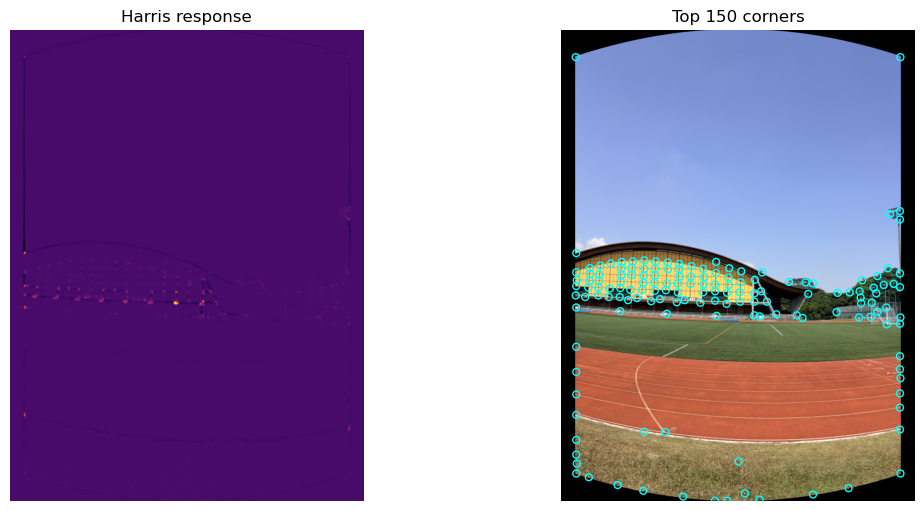

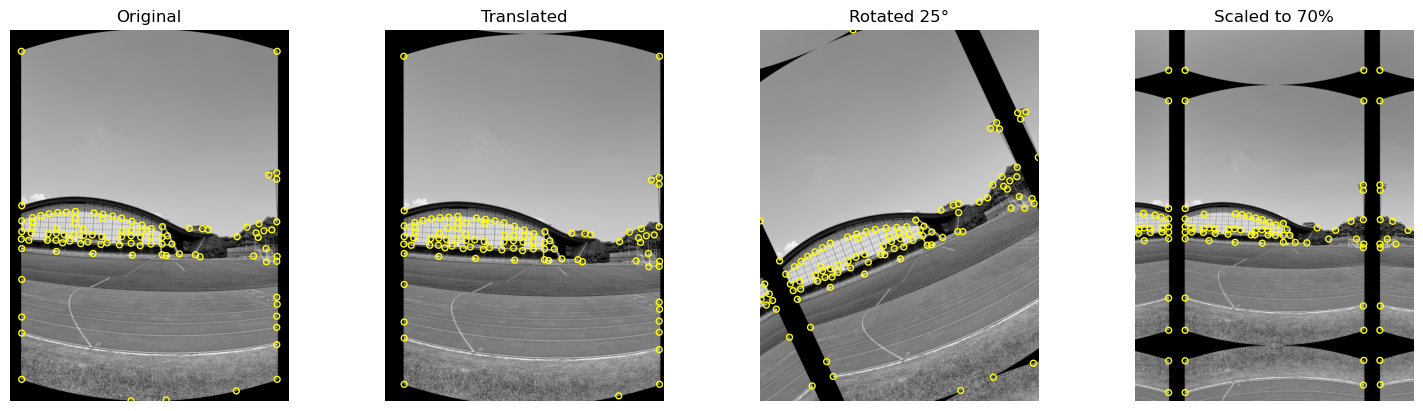

In [2]:
def normalize01(array):
    return (array - array.min()) / (array.max() - array.min() + 1e-12)

def harris_response(gray, sigma=1.5, k=0.04):
    gray = gray.astype(np.float32) / 255.0
    ix = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    iy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

    sxx = cv2.GaussianBlur(ix * ix, (0, 0), sigma)
    syy = cv2.GaussianBlur(iy * iy, (0, 0), sigma)
    sxy = cv2.GaussianBlur(ix * iy, (0, 0), sigma)

    determinant = sxx * syy - sxy * sxy
    trace = sxx + syy

    return determinant - k * trace * trace

def local_maxima(response, count=150, radius=8, threshold=0.01):
    size = 2 * radius + 1
    peak = response == cv2.dilate(response, np.ones((size, size), np.uint8))
    yy, xx = np.nonzero(peak & (response > threshold * response.max()))
    order = np.argsort(response[yy, xx])[::-1][:count]
    return np.column_stack([xx[order], yy[order]])

test_index = 4
response = harris_response(grays[test_index])
corners = local_maxima(response)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
axes[0].imshow(normalize01(response), cmap="inferno")
axes[0].set_title("Harris response")
axes[1].imshow(images[test_index])
axes[1].scatter(corners[:, 0], corners[:, 1], s=25,
                facecolors="none", edgecolors="cyan")
axes[1].set_title(f"Top {len(corners)} corners")
for ax in axes:
    ax.axis("off")
plt.show()

h, w = grays[test_index].shape
variants = [
    grays[test_index],
    cv2.warpAffine(grays[test_index], np.float32([[1, 0, 18], [0, 1, 12]]),
                   (w, h), borderMode=cv2.BORDER_REFLECT),
    cv2.warpAffine(grays[test_index], cv2.getRotationMatrix2D((w/2, h/2), 25, 1),
                   (w, h), borderMode=cv2.BORDER_REFLECT),
    cv2.warpAffine(grays[test_index], cv2.getRotationMatrix2D((w/2, h/2), 0, .7),
                   (w, h), borderMode=cv2.BORDER_REFLECT),
]
titles = ["Original", "Translated", "Rotated 25°", "Scaled to 70%"]

fig, axes = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
for ax, variant, title in zip(axes, variants, titles):
    points = local_maxima(harris_response(variant), count=100)
    ax.imshow(variant, cmap="gray")
    ax.scatter(points[:, 0], points[:, 1], s=18,
               facecolors="none", edgecolors="yellow")
    ax.set_title(title)
    ax.axis("off")
plt.show()

pixels above the 0.01 * max threshold at all: 9545
  top 150 raw response pixels    distinct structures >= 8px apart:  18   median nearest-neighbour gap:   1.00 px
  top 150 after NMS (radius 8)   distinct structures >= 8px apart: 150   median nearest-neighbour gap:  17.01 px
  of the 150 NMS corners plotted above, 37 lie on that synthetic border rather than on scene content

repeatability = fraction of the reference corners inside the mapped region that reappear within the tolerance

transform               scored  found  rep@2px  rep@3px  rep@5px  median err
identity (control)         150    150  100.00%  100.00%  100.00%       0.00px
translate (18, 12)         148    150  100.00%  100.00%  100.00%       0.00px
translate (0.5, 0.5)       150    150   86.67%   88.00%   90.00%       0.71px
rotate 2 deg               150    150   80.67%   85.33%   86.67%       0.69px
rotate 5 deg               150    150   80.00%   86.00%   87.33%       0.70px
rotate 10 deg              150    150   90.

scale 90%                  150    137   78.67%   80.00%   80.67%       0.55px
scale 80%                  150    126   63.33%   65.33%   67.33%       0.88px
scale 70%                  150    101   48.67%   50.67%   54.00%       2.50px
scale 60%                  150     77   38.00%   40.67%   44.00%       6.63px
scale 50%                  150     62   26.67%   30.67%   34.00%       8.50px


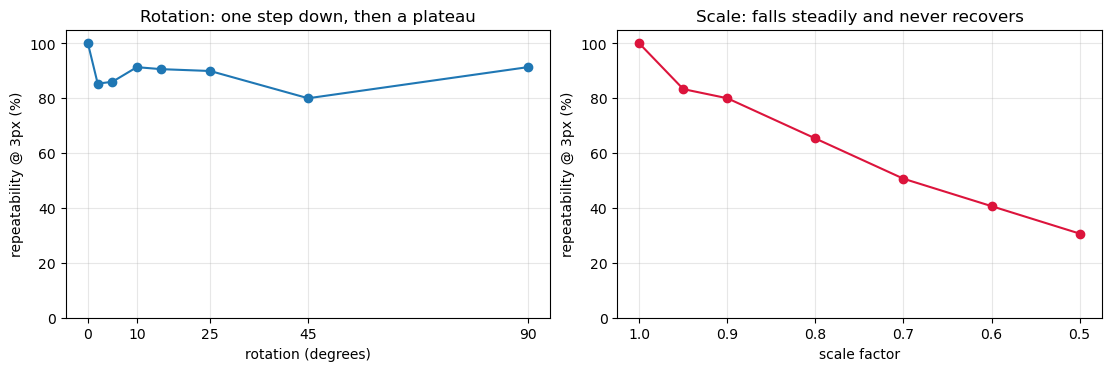

In [3]:
# --- Questions A1-A2: measure the claims rather than assert them ----------------
# A1. What does non-maximum suppression buy? Compare the 150 strongest raw response
# pixels with the 150 strongest *separated* peaks that local_maxima returns.
def separated_count(points, radius=8):
    kept = []
    for point in points:
        if all(np.hypot(*(point - other)) >= radius for other in kept):
            kept.append(point)
    return len(kept)

order = np.argsort(response, axis=None)[::-1][:150]
raw_peaks = np.column_stack(np.unravel_index(order, response.shape))[:, ::-1]
print(f"pixels above the 0.01 * max threshold at all: "
      f"{int((response > 0.01 * response.max()).sum())}")
for name, points in (("top 150 raw response pixels", raw_peaks),
                     ("top 150 after NMS (radius 8)", corners)):
    gaps = np.linalg.norm(points[:, None, :] - points[None, :, :], axis=2).astype(float)
    np.fill_diagonal(gaps, np.inf)
    print(f"  {name:30s} distinct structures >= 8px apart: "
          f"{separated_count(points):3d}   median nearest-neighbour gap: "
          f"{np.median(gaps.min(axis=1)):6.2f} px")

# The cylindrical warp leaves a synthetic black border, and its edge is a very strong
# corner in its own right - which is why part (c) hands `valid_mask` to the detector.
rows, cols = grays[test_index].shape
content = cv2.erode((valid_masks[test_index] > 0).astype(np.uint8),
                    np.ones((11, 11), np.uint8)) > 0
print(f"  of the 150 NMS corners plotted above, "
      f"{int((~content[corners[:, 1], corners[:, 0]]).sum())} lie on that synthetic "
      f"border rather than on scene content")

# A2. Repeatability under known transforms. Every variant comes from a known affine, so
# the true position of each original corner is known exactly. Three precautions keep the
# measurement honest: detection is confined to real scene content, the response is masked
# to the region the transform actually maps into so the budget is not spent on
# BORDER_REFLECT padding, and only reference corners whose true position lands in that
# same region are scored.
centre = (cols / 2, rows / 2)
BUDGET = 150

def detect_in(gray, keep, count=BUDGET):
    masked = harris_response(gray)
    masked[~keep] = masked.min()
    return local_maxima(masked, count=count)

reference_corners = detect_in(grays[test_index], content)

def repeatability(affine):
    variant = cv2.warpAffine(grays[test_index], affine, (cols, rows),
                             borderMode=cv2.BORDER_REFLECT)
    footprint = cv2.warpAffine(content.astype(np.uint8) * 255, affine,
                               (cols, rows), flags=cv2.INTER_NEAREST) > 0
    found = detect_in(variant, footprint)
    truth = cv2.transform(reference_corners.reshape(-1, 1, 2).astype(np.float32),
                          affine).reshape(-1, 2)
    inside = ((truth[:, 0] >= 0) & (truth[:, 0] < cols) &
              (truth[:, 1] >= 0) & (truth[:, 1] < rows))
    truth = truth[inside]
    truth = truth[footprint[truth[:, 1].astype(int), truth[:, 0].astype(int)]]
    if len(truth) == 0 or len(found) == 0:
        return np.array([np.inf]), 0, len(found)
    nearest = np.linalg.norm(truth[:, None, :] - found[None, :, :], axis=2).min(axis=1)
    return nearest, len(truth), len(found)

angles = [0, 2, 5, 10, 15, 25, 45, 90]
scales = [1.0, 0.95, 0.9, 0.8, 0.7, 0.6, 0.5]
cases = [("identity (control)", np.float32([[1, 0, 0], [0, 1, 0]]))]
cases += [(f"translate ({dx}, {dy})", np.float32([[1, 0, dx], [0, 1, dy]]))
          for dx, dy in ((18, 12), (0.5, 0.5))]
cases += [(f"rotate {angle} deg", cv2.getRotationMatrix2D(centre, angle, 1))
          for angle in angles[1:]]
cases += [(f"scale {scale:.0%}", cv2.getRotationMatrix2D(centre, 0, scale))
          for scale in scales[1:]]

print(f"\nrepeatability = fraction of the reference corners inside the mapped region "
      f"that reappear within the tolerance\n")
print(f"{'transform':22s} {'scored':>7s} {'found':>6s} "
      f"{'rep@2px':>8s} {'rep@3px':>8s} {'rep@5px':>8s} {'median err':>11s}")
curves = {}
for name, affine in cases:
    nearest, scored, found = repeatability(affine)
    rates = [(nearest <= t).mean() for t in (2, 3, 5)]
    curves[name] = rates[1]
    print(f"{name:22s} {scored:7d} {found:6d} "
          f"{rates[0]:8.2%} {rates[1]:8.2%} {rates[2]:8.2%} {np.median(nearest):10.2f}px")

angle_curve = [curves["identity (control)"]] + [curves[f"rotate {a} deg"] for a in angles[1:]]
scale_curve = [curves["identity (control)"]] + [curves[f"scale {s:.0%}"] for s in scales[1:]]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
axes[0].plot(angles, np.array(angle_curve) * 100, "o-")
axes[0].set_xlabel("rotation (degrees)"); axes[0].set_xticks([0, 10, 25, 45, 90])
axes[0].set_title("Rotation: one step down, then a plateau")
axes[1].plot(scales, np.array(scale_curve) * 100, "o-", color="crimson")
axes[1].set_xlabel("scale factor"); axes[1].invert_xaxis()
axes[1].set_title("Scale: falls steadily and never recovers")
for ax in axes:
    ax.set_ylabel("repeatability @ 3px (%)"); ax.set_ylim(0, 105); ax.grid(alpha=.3)
plt.show()

#### Answers A1-A2

**A1. What was completed.** `harris_response` needed the two remaining smoothed products and the two invariants of the second-moment matrix:

```python
syy = cv2.GaussianBlur(iy * iy, (0, 0), sigma)
sxy = cv2.GaussianBlur(ix * iy, (0, 0), sigma)
determinant = sxx * syy - sxy * sxy
trace       = sxx + syy
```

so that $R=\det(M)-k\,\mathrm{trace}(M)^2$ with $M=G_\sigma*\begin{bmatrix}I_x^2 & I_xI_y\\ I_xI_y & I_y^2\end{bmatrix}$. The Gaussian is applied to the *products* of the gradients, not to the gradients themselves — that ordering is what makes $M$ a summary of the gradient distribution over a neighbourhood rather than a property of a single pixel.

**What the response map shows.** Almost the whole frame is flat and dark. The response concentrates on the sports hall's glazed facade, where the vertical mullions cross the horizontal transoms in a dense grid, and picks up the floodlight lattice, the junctions where the white lane lines meet the painted lane numbers, and the roof edge where it meets the sky. The sky, the grass and the uniform red track — which together are most of the image — return essentially nothing, because a constant region has no gradient at all and a smooth gradient has gradient energy in only one direction.

**Why non-maximum suppression is required.** Three measurements from the cell above make the case concretely:

| | pixels | distinct structures $\ge 8$px apart | median nearest-neighbour gap |
|---|---|---|---|
| above the `0.01 * max` threshold | 9 545 | — | — |
| top 150 by **raw** response | 150 | **18** | **1.00 px** |
| top 150 after NMS (radius 8) | 150 | **150** | **17.01 px** |

The reason is that $R$ is not a spiky function. $M$ is built by convolving the gradient products with a Gaussian of $\sigma = 1.5$ on top of a $3\times3$ Sobel, so the operator has a support of roughly 5–9 px and a single physical corner produces a smooth *blob* of high response several pixels across, not one bright pixel. Ranking pixels by $R$ and taking the top 150 therefore spends almost the entire budget re-detecting a handful of the very strongest corners: the 150 highest-response pixels are neighbours of each other (median gap of exactly 1 px) and represent only **18** genuine structures. After suppression each of the 150 detections is a distinct structure, and they are spread across the frame with a median spacing of 17 px.

Two things follow, and both matter downstream:

1. **Localization.** Without NMS a corner is reported as a cluster, so there is no well-defined position to hand to a descriptor or to a homography estimate. NMS keeps only the crest of the blob.
2. **Coverage.** Section (c) fits a transform from correspondences. Points concentrated in 18 clumps are a nearly degenerate configuration; 150 well-separated points across the frame constrain it properly.

The implementation is a neat trick worth naming: `response == cv2.dilate(response, np.ones((2r+1, 2r+1)))` is true exactly where a pixel equals the maximum of its $(2r+1)^2$ neighbourhood, because grayscale dilation *is* a local maximum filter. The extra `response > threshold * response.max()` test then discards local maxima that are only locally strong — every flat patch has a maximum somewhere.

One honest caveat visible in the figure: **37 of the 150 plotted corners lie on the synthetic black-border edge** left by the cylindrical warp rather than on scene content. That boundary is a perfectly straight, maximum-contrast step, so its ends and its curvature register strongly. This is precisely why part (c) passes `valid_mask` into `detectAndCompute` instead of detecting on the raw warped frame, and why the measurement below confines detection to real content.

---

**A2. Repeatability under translation, rotation and scaling.** Every variant is produced by a known affine, so the true position of each original corner in the variant is known exactly and "repeatability" can be measured rather than asserted. Detection is confined to genuine scene content (the cylindrical validity mask, eroded by 5 px) and, in each variant, to the region the affine actually maps into, so the `BORDER_REFLECT` padding is neither credited nor blamed. Both images get the same budget of 150 detections. A reference corner counts as repeated if some detection in the variant lies within the tolerance of its true position.

| transform | corners scored | found in variant | rep @2px | rep @3px | rep @5px | median error |
|---|---|---|---|---|---|---|
| identity (control) | 150 | 150 | 100.00% | 100.00% | 100.00% | 0.00 px |
| translate (18, 12) | 148 | 150 | **100.00%** | **100.00%** | 100.00% | 0.00 px |
| translate (0.5, 0.5) | 150 | 150 | 86.67% | **88.00%** | 90.00% | 0.71 px |
| rotate 2° | 150 | 150 | 80.67% | 85.33% | 86.67% | 0.69 px |
| rotate 5° | 150 | 150 | 80.00% | 86.00% | 87.33% | 0.70 px |
| rotate 10° | 150 | 150 | 90.67% | 91.33% | 92.67% | 0.60 px |
| rotate 15° | 149 | 150 | 88.59% | 90.60% | 91.95% | 0.52 px |
| rotate 25° | 149 | 150 | 87.92% | 89.93% | 89.93% | 0.58 px |
| rotate 45° | 150 | 150 | 78.67% | **80.00%** | 81.33% | 0.63 px |
| rotate 90° | 139 | 150 | 89.93% | 91.37% | 93.53% | 0.71 px |
| scale 95% | 150 | 150 | 82.67% | 83.33% | 86.00% | 0.58 px |
| scale 90% | 150 | 137 | 78.67% | 80.00% | 80.67% | 0.55 px |
| scale 80% | 150 | 126 | 63.33% | 65.33% | 67.33% | 0.88 px |
| scale 70% | 150 | 101 | 48.67% | 50.67% | 54.00% | 2.50 px |
| scale 60% | 150 | 77 | 38.00% | 40.67% | 44.00% | 6.63 px |
| scale 50% | 150 | **62** | 26.67% | **30.67%** | 34.00% | 8.50 px |

**Scaling changes repeatability most, by a wide margin.** At half scale only 30.67% of corners survive, against a worst case of 80.00% across the entire rotation range. Taking each transform in turn:

**Translation is exact — but only for whole pixels.** The integer shift of (18, 12) scores a perfect 100.00% with zero median error, which is what the mathematics demands: a whole-pixel shift is a pure re-indexing of the array, so every Sobel and every Gaussian sees an identical neighbourhood and $R$ is shifted verbatim. The interesting row is the *sub-pixel* shift of (0.5, 0.5), which drops to **88.00%**. Nothing about Harris changed there; the image did. A half-pixel shift can only be realised by bilinear resampling, which is a mild low-pass filter, and that is enough to push 12% of corners below threshold or move them past the tolerance. The median error of 0.71 px is exactly $\sqrt{0.5^2+0.5^2}$ — the detector reports integer pixel positions, so it cannot represent a half-pixel truth. This is worth separating from the operator's own behaviour: it is a *sampling* limit, and it sets a floor of roughly 88–91% that every non-trivial warp below inherits.

**Rotation is invariant in theory and slightly less so in practice.** $R$ is built only from $\det(M)$ and $\mathrm{trace}(M)$, and the determinant and trace of a symmetric $2\times2$ matrix are invariant under $M \mapsto Q M Q^{\mathsf T}$ for orthogonal $Q$ — that is, under rotation of the coordinate frame. So in exact continuous mathematics Harris *is* rotation invariant, and the measured plateau of roughly 85–91% (against the 88% resampling floor) confirms it. The residual loss is entirely discretization, and it has a clear signature: the worst point in the whole sweep is **45° at 80.00%**, and 90° recovers to **91.37%**, above every intermediate angle. Two axis-aligned approximations explain that shape.

- The $3\times3$ Sobel is a separable, axis-aligned derivative estimator. Its frequency response is anisotropic — most faithful along the image axes, least at 45° — so the estimated $I_x, I_y$ (and hence $M$) are subtly angle-dependent.
- `local_maxima` suppresses over a **square** $(2r+1)^2$ window, whose reach along the diagonal is $\sqrt2$ times its reach along the axes. A square window is not rotation invariant, and the mismatch is again maximal at 45°.

At 90° the sampling grid maps onto itself, both approximations are back in alignment, and the only remaining cost is the half-pixel offset of the rotation centre — which is why 90° lands right at the sub-pixel-translation floor. (The small wiggles between 2°, 5° and 10° are detector noise around the response threshold, not a trend; the reliable features of the curve are the immediate step down from 100%, the 45° dip and the 90° recovery.)

**Scaling breaks Harris outright, and this is a property of the operator, not of resampling.** The decline is monotonic and severe, and the `found` column shows why it is qualitatively different from the other two rows: from 90% downwards the detector can no longer even fill its budget of 150. At half scale only **62** pixels in the entire footprint clear the `0.01 * max` threshold. Corner *structures* are disappearing, not merely moving — which is also why the median error explodes to 8.50 px, since the surviving reference corners are being matched to unrelated detections.

The cause is that Harris has two scales hard-coded and no way to adapt either:

- a **differentiation scale**, fixed by the $3\times3$ Sobel at about 1 px, and
- an **integration scale**, fixed by $\sigma = 1.5$ at about 5–9 px.

Together they ask one fixed question: *within about eight pixels, does the gradient point in two independent directions?* Whether a given piece of the world answers yes depends on its size **in pixels**, and rescaling changes exactly that. A corner whose two edges met over 8 px now meets over 4; the Gaussian merges them into a single blurred edge, $M$ becomes effectively rank-one, $\det(M) \to 0$, and $R$ falls below threshold. Meanwhile texture that was previously too fine to register — the grass, the mullion grid at reduced scale — aliases into new spurious responses that were not there before. Nothing in $R=\det(M)-k\,\mathrm{trace}(M)^2$ notices any of this.

If anything the measurement is *generous* to the scaled cases: the variant is given its full 150-detection budget inside the shrunken footprint, while the reference contributes only whichever of its top 150 happen to fall there. The true degradation is at least this bad.

Harris is also not scale-*covariant*, which is the deeper problem: even for the corners it does re-find, it reports no size, so there is no characteristic scale with which to normalise a descriptor patch. That is exactly what section (b) fixes — SIFT searches for extrema of the Difference-of-Gaussians over a pyramid of $\sigma$, so the integration scale is *selected per keypoint* instead of fixed, and each keypoint carries its own `size`.

## (b) SIFT keypoints and descriptors - 15 minutes

SIFT assigns a scale and orientation to each keypoint. A (4\times4) grid of 8-bin orientation histograms gives a **128-dimensional descriptor**.

### Question B1

Detect SIFT features in the fifth image. Report the keypoint count, descriptor shape, and the size and angle ranges.

### Question B2

Rotate the image by 25° and scale it to 80%. Match descriptors using two nearest neighbours and Lowe's ratio test. Why is the ratio test safer than accepting the nearest match alone?

keypoints: 1202
descriptor shape: (1202, 128)
size range: (1.7965353727340698, 97.53516387939453)
angle range: (0.13904571533203125, 359.8753356933594)


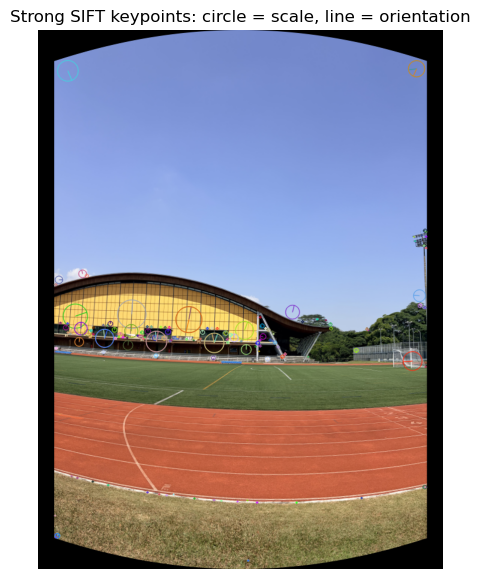

Ratio-test matches: 463


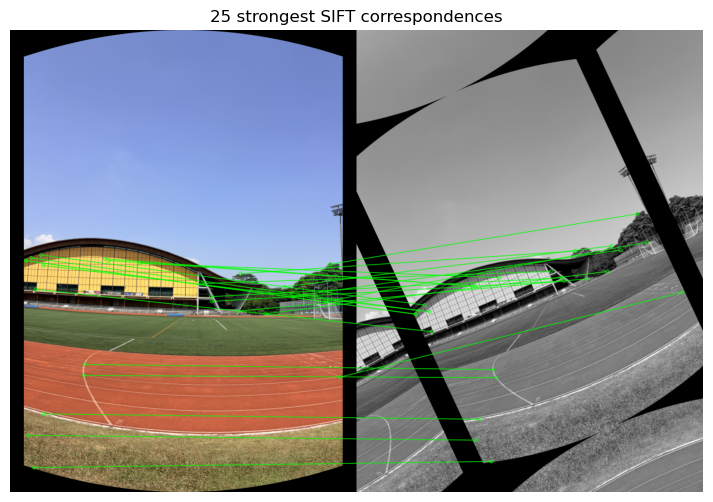

In [4]:
sift = cv2.SIFT_create(nfeatures=1200)

keypoints, descriptors = sift.detectAndCompute(grays[test_index], None)

print("keypoints:", len(keypoints))
print("descriptor shape:", descriptors.shape)
print("size range:", (min(k.size for k in keypoints), max(k.size for k in keypoints)))
print("angle range:", (min(k.angle for k in keypoints), max(k.angle for k in keypoints)))

strong = sorted(keypoints, key=lambda k: k.response, reverse=True)[:180]
keypoint_view = cv2.drawKeypoints(
    images[test_index], strong, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
)
plt.figure(figsize=(7, 7))
plt.imshow(keypoint_view)
plt.title("Strong SIFT keypoints: circle = scale, line = orientation")
plt.axis("off")
plt.show()

matrix = cv2.getRotationMatrix2D((w/2, h/2), 25, .8)
transformed_gray = cv2.warpAffine(grays[test_index], matrix, (w, h),
                                  borderMode=cv2.BORDER_REFLECT)
transformed_rgb = cv2.cvtColor(transformed_gray, cv2.COLOR_GRAY2RGB)


keypoints_t, descriptors_t = sift.detectAndCompute(transformed_gray, None)
pairs = cv2.BFMatcher(cv2.NORM_L2).knnMatch(descriptors, descriptors_t, k=2)
good_matches = [m for m, n in pairs if m.distance < 0.75 * n.distance]

best_matches = sorted(good_matches, key=lambda m: m.distance)[:25]
match_view = cv2.drawMatches(
    images[test_index], keypoints, transformed_rgb, keypoints_t,
    best_matches, None, matchColor=(0, 255, 0),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)
print(f"Ratio-test matches: {len(good_matches)}")
plt.figure(figsize=(14, 6))
plt.imshow(match_view)
plt.title("25 strongest SIFT correspondences")
plt.axis("off")
plt.show()

keypoints: 1202 original, 1201 transformed
correct correspondences recoverable at all: 477

criterion                            kept  correct  precision   recall
nearest neighbour only               1202      477     39.68%  100.00%
absolute distance, equal yield        463      401     86.61%   84.07%
Lowe ratio test < 0.75                463      439     94.82%   92.03%

ratio d1/d2 for correct matches:   median 0.283, 90th pct 0.714
ratio d1/d2 for incorrect matches: median 0.960, 10th pct 0.860
descriptor distance overlaps far more: correct median 57.4, incorrect median 302.4


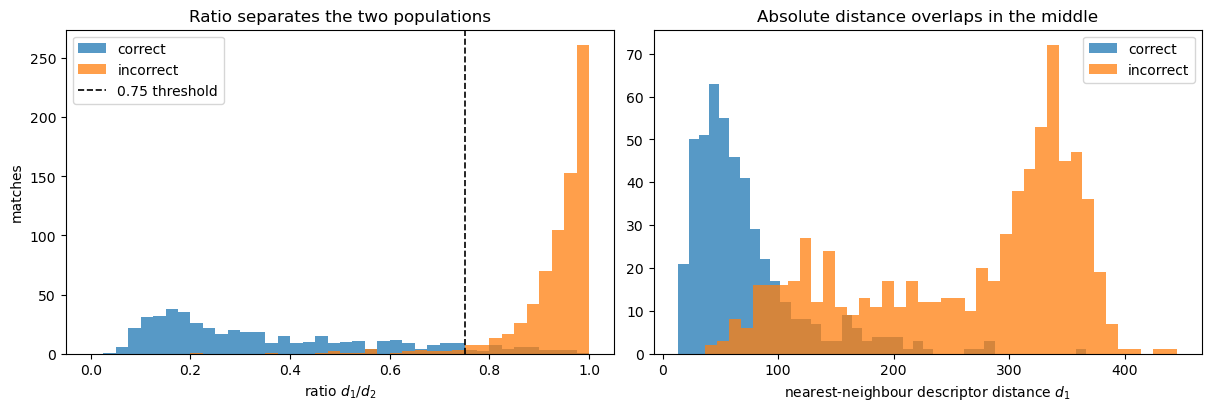

In [5]:
# --- Question B2: is the ratio test actually safer? Score it against ground truth ---
# `matrix` is the exact affine used to build the transformed image, so a match is
# verifiably correct when the query keypoint, projected through `matrix`, lands on
# its claimed partner. That turns "safer" into a measurable precision.
TOLERANCE = 3.0

def match_error(matches):
    if not matches:
        return np.empty(0)
    source = np.float32([keypoints[m.queryIdx].pt for m in matches])
    target = np.float32([keypoints_t[m.trainIdx].pt for m in matches])
    projected = cv2.transform(source.reshape(-1, 1, 2), matrix).reshape(-1, 2)
    return np.linalg.norm(projected - target, axis=1)

nearest_only = [p[0] for p in pairs]
ratios = np.float32([p[0].distance / max(p[1].distance, 1e-12) for p in pairs])
correct_available = int((match_error(nearest_only) <= TOLERANCE).sum())

# A fair third contender: an absolute descriptor-distance cutoff tuned to return
# exactly as many matches as the ratio test, so only the *criterion* differs.
absolute = sorted(nearest_only, key=lambda m: m.distance)[:len(good_matches)]

print(f"keypoints: {len(keypoints)} original, {len(keypoints_t)} transformed")
print(f"correct correspondences recoverable at all: {correct_available}\n")
print(f"{'criterion':34s} {'kept':>6s} {'correct':>8s} {'precision':>10s} {'recall':>8s}")
for name, subset in (("nearest neighbour only", nearest_only),
                     (f"absolute distance, equal yield", absolute),
                     ("Lowe ratio test < 0.75", good_matches)):
    errors = match_error(subset)
    correct = int((errors <= TOLERANCE).sum())
    print(f"{name:34s} {len(subset):6d} {correct:8d} "
          f"{correct / max(len(subset), 1):10.2%} {correct / max(correct_available, 1):8.2%}")

errors_all = match_error(nearest_only)
good_mask = errors_all <= TOLERANCE
print(f"\nratio d1/d2 for correct matches:   median {np.median(ratios[good_mask]):.3f}, "
      f"90th pct {np.percentile(ratios[good_mask], 90):.3f}")
print(f"ratio d1/d2 for incorrect matches: median {np.median(ratios[~good_mask]):.3f}, "
      f"10th pct {np.percentile(ratios[~good_mask], 10):.3f}")
print(f"descriptor distance overlaps far more: correct median "
      f"{np.median([m.distance for m, k in zip(nearest_only, good_mask) if k]):.1f}, "
      f"incorrect median "
      f"{np.median([m.distance for m, k in zip(nearest_only, good_mask) if not k]):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(ratios[good_mask], bins=40, range=(0, 1), alpha=.75, label="correct")
axes[0].hist(ratios[~good_mask], bins=40, range=(0, 1), alpha=.75, label="incorrect")
axes[0].axvline(0.75, color="k", ls="--", lw=1.2, label="0.75 threshold")
axes[0].set_xlabel("ratio $d_1/d_2$"); axes[0].set_ylabel("matches"); axes[0].legend()
axes[0].set_title("Ratio separates the two populations")
distances = np.float32([m.distance for m in nearest_only])
axes[1].hist(distances[good_mask], bins=40, alpha=.75, label="correct")
axes[1].hist(distances[~good_mask], bins=40, alpha=.75, label="incorrect")
axes[1].set_xlabel("nearest-neighbour descriptor distance $d_1$"); axes[1].legend()
axes[1].set_title("Absolute distance overlaps in the middle")
plt.show()

#### Answers B1-B2

**B1. Completion and statistics.** The detection was a single call, `sift.detectAndCompute(grays[test_index], None)`, on image 5 (`test_index = 4`).

| quantity | value |
|---|---|
| keypoints | **1202** |
| descriptor array | **(1202, 128)** |
| `size` range | **1.797 → 97.535 px** |
| `angle` range | **0.139° → 359.875°** |

Four things are worth reading off those numbers.

**1202, not 1200.** `nfeatures=1200` is a retention target, not a hard cap: OpenCV ranks keypoints by contrast and truncates, keeping every keypoint tied at the cut-off, so the count can overshoot slightly.

**128 = 4 × 4 × 8.** The descriptor is a $4\times4$ spatial grid of cells, each holding an 8-bin orientation histogram. It is computed on gradients that have already been rotated by the keypoint's own `angle` and sampled at the keypoint's own `size`, which is what makes the *descriptor* invariant to rotation and scale rather than just the detector. It is then L2-normalised, clipped at 0.2 and renormalised, which buys invariance to affine changes in illumination (the clip specifically limits the influence of a few very large gradients, e.g. a specular glint).

**A 54× spread in `size`.** This is the direct evidence that scale is being *selected*, not assumed — precisely what A2 showed Harris cannot do. The small end comes from grass and foliage texture and the fine mullion spacing; the large end from the roof arch and the mass of the building.

**`angle` spans essentially the full circle.** Orientation is assigned from a histogram of local gradient directions, with no prior, so in a scene containing structure at every inclination — a curved roof, radiating lane lines, tree canopy — all orientations occur. In the rich-keypoint figure this is visible directly: each circle's radius is the keypoint's scale and the radial line is its orientation, and the circles cluster densely on the facade grid, the roof edge, the floodlight mast and the track markings, and are nearly absent from the sky.

---

**B2. Why the ratio test is safer than taking the nearest match.** The transformed image is built with a known affine (25°, scaled to 80%), so a match can be *checked*: project the query keypoint through that matrix and see whether it lands on its claimed partner (tolerance 3 px). That turns "safer" into a number. Three criteria were compared on identical descriptors — the only thing that differs is the decision rule.

| criterion | kept | correct | precision | recall |
|---|---|---|---|---|
| nearest neighbour only | 1202 | 477 | **39.68%** | 100.00% |
| absolute descriptor distance, tuned to the *same yield* | 463 | 401 | 86.61% | 84.07% |
| **Lowe ratio test, $d_1/d_2 < 0.75$** | 463 | 439 | **94.82%** | **92.03%** |

And the two decision variables, separated by whether the match is actually right:

| | correct matches | incorrect matches |
|---|---|---|
| ratio $d_1/d_2$ | median **0.283** (90th pct 0.714) | median **0.960** (10th pct 0.860) |
| distance $d_1$ | median 57.4 | median 302.4 |

The histograms show the same thing. The ratio splits into two almost disjoint populations — a broad hump below 0.6 and a hard spike against 1.0 — with the 0.75 threshold sitting in the gap between them. The raw distance separates on average but overlaps badly through the 80–250 band, and that overlap is exactly where the 62 errors of the equal-yield absolute cutoff come from. Held to the same yield of 463 matches, the ratio test converts 38 of them from wrong to right, an 8.2-point gain in precision that comes purely from the criterion.

**Why the ratio works and an absolute threshold cannot.**

1. **Descriptor density is wildly non-uniform, even within one image.** A patch on the facade's repeating mullion grid has hundreds of near-identical rivals; the roof apex has none. A single global distance threshold has to serve both: set it tight and every match in textured regions is discarded, set it loose and every repeated structure yields a confident absurdity. There is no value that is right in both places.
2. **The ratio is self-normalising.** $d_2$ is measured from the *same* query descriptor into the *same* database, so it is a free, per-feature estimate of the local background distance. The test asks not "is this match close?" but "is this match *distinctively* closer than the best alternative?" — which is the question that actually determines whether the correspondence is unique.
3. **It has a clean null hypothesis.** If the query has no true partner, $d_1$ and $d_2$ are both draws from the same background distribution of unrelated descriptors, so their ratio concentrates just below 1 — the measured spike at 0.960. A genuine match pulls $d_1$ far below that background, so the ratio is small. Lowe calibrated 0.75–0.8 from exactly these two empirical distributions.

**And there is a failure mode no distance threshold can fix.** Only **477 of 1202** original keypoints (39.7%) have a correct partner *at all*. The 25° rotation and 0.8 scaling change which DoG extrema survive detection — the same repeatability effect measured in A2, now for SIFT — so for the other 60% the nearest neighbour is *necessarily* wrong. No threshold can conjure a match that does not exist; what the ratio test can do is **recognise** that the best candidate is not distinctive and refuse it, which is why its recall of 92.03% is measured against the 477 recoverable matches rather than against all 1202 keypoints.

**The honest limitation:** the ratio test throws away correct matches on genuinely repeated structure — it lost 8% of the recoverable ones here, and the mullion grid is exactly the place where a true match has a near-identical rival. That residue is what RANSAC is for, and section (c) shows it still finds 8–29% of ratio-test survivors to be geometric outliers.

## (c) Build a panorama from 10 photographs - 25 minutes

The pipeline is:

1. match SIFT descriptors in every adjacent pair;
2. use RANSAC to reject geometrically inconsistent matches;
3. after cylindrical projection, summarize the inlier motion by a stable translation;
4. chain the translations to a central reference image;
5. warp and feather-blend all images; and
6. clip the curved black border to a valid rectangle.

### Question C1 - match adjacent images

Complete `match_adjacent`. Print match and RANSAC statistics for all nine pairs and visualize the strongest inliers for one pair.

pair   good   inliers   ratio
01-02    491      386    0.786
02-03    622      572    0.920
03-04    573      484    0.845
04-05    618      555    0.898
05-06    590      472    0.800
06-07    567      498    0.878
07-08    566      467    0.825
08-09    629      483    0.768
09-10    535      379    0.708


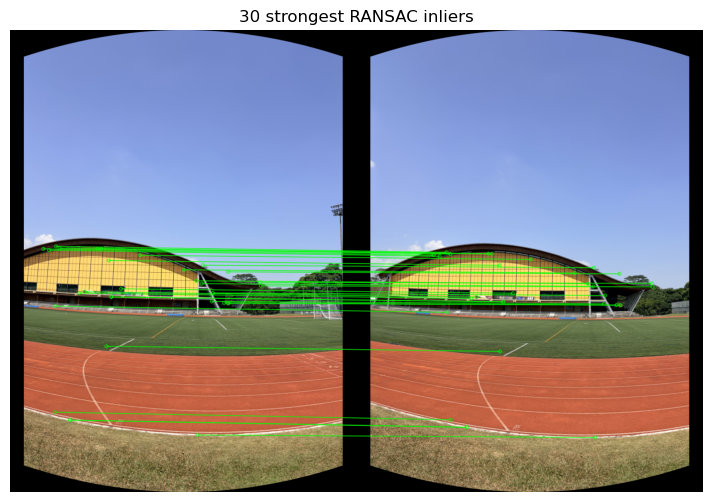

In [6]:
def detect_sift(rgb, valid_mask):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    return cv2.SIFT_create(nfeatures=1600).detectAndCompute(gray, valid_mask)

def match_adjacent(image_a, mask_a, image_b, mask_b, ratio=0.72):
    kp_a, des_a = detect_sift(image_a, mask_a)
    kp_b, des_b = detect_sift(image_b, mask_b)
    pairs = cv2.BFMatcher(cv2.NORM_L2).knnMatch(des_a, des_b, k=2)

    good = [m for m, n in pairs if m.distance < ratio * n.distance]
    src = np.float32([kp_a[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([kp_b[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 3.0)
    inliers = mask.ravel().astype(bool)


    delta = dst[inliers, 0] - src[inliers, 0]
    dx, dy = np.median(delta, axis=0)
    transform = np.float32([[1.0, 0.0, dx],
                            [0.0, 1.0, dy],
                            [0.0, 0.0, 1.0]])

    return {"kp_a": kp_a, "kp_b": kp_b, "matches": good,
            "H": H, "inliers": inliers, "transform": transform}

pairwise = [
    match_adjacent(images[i], valid_masks[i], images[i+1], valid_masks[i+1])
    for i in range(9)
]

print("pair   good   inliers   ratio")
for i, result in enumerate(pairwise):
    good = len(result["matches"])
    inlier_count = int(result["inliers"].sum())
    print(f"{i+1:02d}-{i+2:02d}   {good:4d}     {inlier_count:4d}    {inlier_count/good:.3f}")

sample_index = 4
sample = pairwise[sample_index]
sample_inliers = [m for m, keep in zip(sample["matches"], sample["inliers"]) if keep]
sample_inliers = sorted(sample_inliers, key=lambda m: m.distance)[:30]
view = cv2.drawMatches(
    images[sample_index], sample["kp_a"], images[sample_index+1], sample["kp_b"],
    sample_inliers, None, matchColor=(0, 255, 0),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)
plt.figure(figsize=(14, 6))
plt.imshow(view)
plt.title("30 strongest RANSAC inliers")
plt.axis("off")
plt.show()

In [7]:
# --- Question C1 follow-up: why a median translation rather than the homography? ---
# On the cylinder a horizontal camera rotation is (to first order) a pure shift, so
# the inlier displacements should form a tight cluster. Measure that spread, and
# compare the median against what the full homography does to the same corners.
print(f"{'pair':>6s} {'good':>5s} {'inl':>5s} {'ratio':>6s} "
      f"{'dx':>8s} {'dy':>7s} {'MAD x':>7s} {'MAD y':>7s} {'H shear/scale err':>18s}")
for i, result in enumerate(pairwise):
    kp_a, kp_b, inliers = result["kp_a"], result["kp_b"], result["inliers"]
    source = np.float32([kp_a[m.queryIdx].pt for m in result["matches"]])[inliers]
    target = np.float32([kp_b[m.trainIdx].pt for m in result["matches"]])[inliers]
    delta = target - source
    dx, dy = np.median(delta, axis=0)
    mad = np.median(np.abs(delta - (dx, dy)), axis=0)
    # How far the homography's own corner mapping departs from a pure shift:
    box = np.float32([[[0, 0]], [[cols, 0]], [[cols, rows]], [[0, rows]]])
    moved = cv2.perspectiveTransform(box, result["H"]).reshape(-1, 2) - box.reshape(-1, 2)
    departure = np.abs(moved - moved.mean(axis=0)).max()
    print(f"{i+1:02d}-{i+2:02d} {len(result['matches']):5d} {int(inliers.sum()):5d} "
          f"{inliers.sum()/len(result['matches']):6.3f} {dx:8.2f} {dy:7.2f} "
          f"{mad[0]:7.2f} {mad[1]:7.2f} {departure:15.1f} px")

overlaps = [abs(np.median(np.float32([r['kp_b'][m.trainIdx].pt for m in r['matches']])[r['inliers']][:, 0]
                          - np.float32([r['kp_a'][m.queryIdx].pt for m in r['matches']])[r['inliers']][:, 0]))
            for r in pairwise]
print(f"\nframe width {cols} px; median |dx| {np.median(overlaps):.0f} px "
      f"-> about {100 * (1 - np.median(overlaps) / cols):.0f}% overlap between neighbours")

  pair  good   inl  ratio       dx      dy   MAD x   MAD y  H shear/scale err
01-02   491   386  0.786   177.26    2.57    2.18    5.04            45.7 px
02-03   622   572  0.920   130.04    1.15    1.03    1.05            18.5 px
03-04   573   484  0.845   117.27   -2.54    1.00    3.52            27.4 px
04-05   618   555  0.898    61.91   -3.69    1.29    2.18             9.8 px
05-06   590   472  0.800    91.94    8.68    5.56    3.85            19.0 px
06-07   567   498  0.878   104.07   -0.82    5.42    3.47            25.6 px
07-08   566   467  0.825   146.95   -1.00    4.14    2.71            19.7 px
08-09   629   483  0.768   122.96   -2.29    5.67    0.94            21.3 px
09-10   535   379  0.708   160.77   11.97    8.48    5.38            31.0 px



frame width 675 px; median |dx| 123 px -> about 82% overlap between neighbours


#### Answer C1

**What was completed.** The comment on the TODO line is slightly misleading: `dx, dy` are already computed on the line above it, as the component-wise median of the RANSAC inlier displacements. What was missing was packaging them as a $3\times3$ homogeneous translation

```python
transform = np.float32([[1.0, 0.0, dx],
                        [0.0, 1.0, dy],
                        [0.0, 0.0, 1.0]])
```

which is the form the rest of the pipeline needs: `chain_to_reference` composes it with `np.eye(3)` by matrix product, and `canvas_geometry` and `stitch_panorama` feed it to `cv2.perspectiveTransform` and `cv2.warpPerspective`.

**All nine adjacent pairs.**

| pair | good | inliers | ratio | dx | dy | MAD x | MAD y | homography's departure from a pure shift |
|---|---|---|---|---|---|---|---|---|
| 01–02 | 491 | 386 | 0.786 | 177.26 | 2.57 | 2.18 | 5.04 | **45.7 px** |
| 02–03 | 622 | 572 | **0.920** | 130.04 | 1.15 | 1.03 | 1.05 | 18.5 px |
| 03–04 | 573 | 484 | 0.845 | 117.27 | −2.54 | 1.00 | 3.52 | 27.4 px |
| 04–05 | 618 | 555 | 0.898 | 61.91 | −3.69 | 1.29 | 2.18 | **9.8 px** |
| 05–06 | 590 | 472 | 0.800 | 91.94 | 8.68 | 5.56 | 3.85 | 19.0 px |
| 06–07 | 567 | 498 | 0.878 | 104.07 | −0.82 | 5.42 | 3.47 | 25.6 px |
| 07–08 | 566 | 467 | 0.825 | 146.95 | −1.00 | 4.14 | 2.71 | 19.7 px |
| 08–09 | 629 | 483 | 0.768 | 122.96 | −2.29 | 5.67 | 0.94 | 21.3 px |
| 09–10 | 535 | 379 | **0.708** | 160.77 | 11.97 | **8.48** | 5.38 | 31.0 px |

**The matching is extremely healthy.** Every pair yields 491–629 ratio-test matches and 379–572 RANSAC inliers, with inlier fractions of 0.708–0.920. Fitting two parameters from several hundred constraints is enormously over-determined, which is why the medians are so stable. The reason is visible in the last diagnostic line: the median $|dx|$ is **123 px** against a frame width of **675 px**, so consecutive frames overlap by about **82%**. That is a very conservative shooting pattern — it is also why ten photographs produce a panorama only 1735 px wide.

**The cylindrical projection really does linearise the motion.** The MAD of the inlier displacements is 1.00–8.48 px in $x$ and 0.94–5.38 px in $y$, against shifts of 62–177 px. The inlier displacement field is a tight cluster around a single vector, which is exactly the claim the pipeline is making: after projecting onto a cylinder, a horizontal camera rotation becomes a horizontal shift, independent of how far the camera has already turned.

**But the homography is finding real non-translational structure, and the pipeline is deliberately discarding it.** The last column measures how far each fitted homography moves the four frame corners *relative to their average* — zero would mean a pure shift. It ranges from 9.8 px to **45.7 px**. Three things contribute: the photographer pivoted about their own body rather than about the optical centre, so there is genuine camera translation (in the source frames the sports hall visibly grows between shots); the assumed focal length $f = 0.95w$ is a guess, not a calibration, so the cylindrical mapping is slightly wrong; and a hand-held phone adds rolling-shutter shear. Chaining eight-parameter homographies would bake all of that into the mosaic and let it compound. Collapsing each to a two-parameter median translation throws away some real signal in exchange for a model that *cannot* shear, stretch or drift in shape no matter how noisy the estimate — and the median specifically makes the estimate insensitive to the residual outliers RANSAC let through.

**The weakest links are the two ends of the sweep.** Pair 09–10 has the lowest inlier fraction (0.708) and the largest MAD (8.48 px in $x$), and pair 01–02 has the largest departure from a pure shift (45.7 px). Both matter later: C2 shows 09–10 dominating the accumulated-error budget, and the C3 ghosting map is worst on the sports hall, in the part of the panorama built from images 01–03.

**The inlier visualization** (images 05 and 06) shows the 30 strongest survivors as a bundle of near-parallel, near-horizontal lines of almost equal length. That parallelism is the visual signature of a pure translation: every correspondence is displaced by the same vector. Where the lines fan out slightly is where parallax is present.

### Question C2 - chain transformations

Choose image 6 (`reference_index = 5`) as the reference. Complete `chain_to_reference`. A central reference shortens the longest chain and limits accumulated drift.

In [8]:
def chain_to_reference(pair_transforms, reference_index=5):
    transforms = [None] * (len(pair_transforms) + 1)
    transforms[reference_index] = np.eye(3)

    # pair_transforms[i] maps image i into image i+1, so left of the reference the
    # chain runs with those transforms and right of it against their inverses.
    for i in range(reference_index - 1, -1, -1):
        transforms[i] = transforms[i + 1] @ pair_transforms[i]
    for i in range(reference_index + 1, len(transforms)):
        transforms[i] = transforms[i - 1] @ np.linalg.inv(pair_transforms[i - 1])
    return transforms

pair_transforms = [result["transform"] for result in pairwise]
transforms = chain_to_reference(pair_transforms)

for i, H in enumerate(transforms):
    origin = cv2.perspectiveTransform(np.float32([[[0, 0]]]), H)[0, 0]
    print(f"image {i+1:02d}: x={origin[0]:7.1f}, y={origin[1]:6.1f}")

image 01: x=  578.4, y=   6.2
image 02: x=  401.2, y=   3.6
image 03: x=  271.1, y=   2.4
image 04: x=  153.9, y=   5.0
image 05: x=   91.9, y=   8.7
image 06: x=    0.0, y=   0.0
image 07: x= -104.1, y=   0.8
image 08: x= -251.0, y=   1.8
image 09: x= -374.0, y=   4.1
image 10: x= -534.8, y=  -7.9


In [9]:
# --- Question C2 follow-up: what does a central reference actually buy? ----------
# First the honest null result: composing pure translations is just adding the
# (dx, dy) pairs, and addition commutes, so the *relative* layout - and therefore the
# canvas - cannot depend on which image is called the reference. Only the number of
# noisy links between an image and the reference changes.
def chain_report(reference_index):
    chained = chain_to_reference(pair_transforms, reference_index)
    origins = np.float32([cv2.perspectiveTransform(np.float32([[[0, 0]]]), H)[0, 0]
                          for H in chained])
    longest = max(reference_index, len(chained) - 1 - reference_index)
    return longest, origins

print(f"{'reference':>10s} {'longest chain':>14s} {'canvas width':>13s} "
      f"{'y drift range':>14s} {'|y| max from ref':>17s}")
for reference in range(len(transforms)):
    longest, origins = chain_report(reference)
    span = origins[:, 0].max() - origins[:, 0].min() + cols
    drift = origins[:, 1].max() - origins[:, 1].min()
    print(f"{reference + 1:10d} {longest:14d} {span:12.0f}px {drift:13.1f}px "
          f"{np.abs(origins[:, 1]).max():16.1f}px")

# What does change is accumulated *error*. Each link contributes the standard error
# of its own median, about 1.253 * sigma / sqrt(n), with sigma estimated robustly
# from the MAD of the inlier displacements. Errors add as a random walk.
sigmas = []
for result in pairwise:
    source = np.float32([result["kp_a"][m.queryIdx].pt for m in result["matches"]])[result["inliers"]]
    target = np.float32([result["kp_b"][m.trainIdx].pt for m in result["matches"]])[result["inliers"]]
    delta = target - source
    mad = np.median(np.abs(delta - np.median(delta, axis=0)), axis=0)
    sigmas.append(1.2533 * 1.4826 * mad / np.sqrt(len(delta)))
sigmas = np.float32(sigmas)
print()
for reference in range(len(transforms)):
    left = np.sqrt((sigmas[:reference] ** 2).sum(axis=0)).max() if reference else 0.0
    right = np.sqrt((sigmas[reference:] ** 2).sum(axis=0)).max() if reference < 9 else 0.0
    print(f"reference {reference + 1:2d}: predicted worst-case accumulated standard error "
          f"{max(left, right):.3f} px")

# And the reason the pipeline reduces each homography to a translation at all: chain
# the raw homographies instead and watch the far frames stretch, exactly as the setup
# section warns.
def chain_homographies(reference_index=5):
    chained = [None] * len(transforms)
    chained[reference_index] = np.eye(3)
    for i in range(reference_index - 1, -1, -1):
        chained[i] = chained[i + 1] @ pairwise[i]["H"]
    for i in range(reference_index + 1, len(chained)):
        chained[i] = chained[i - 1] @ np.linalg.inv(pairwise[i - 1]["H"])
    return chained

box = np.float32([[[0, 0]], [[cols, 0]], [[cols, rows]], [[0, rows]]])
homography_chain = chain_homographies()
print(f"\n{'image':>6s} {'links':>6s} {'translation chain':>19s} "
      f"{'homography chain':>19s} {'area ratio':>11s}")
shifted, stretched = [], []
for i, (translation_H, homography_H) in enumerate(zip(transforms, homography_chain)):
    a = cv2.perspectiveTransform(box, translation_H).reshape(-1, 2)
    b = cv2.perspectiveTransform(box, homography_H).reshape(-1, 2)
    shifted.append(a)
    stretched.append(b)
    size_a = a.max(axis=0) - a.min(axis=0)
    size_b = b.max(axis=0) - b.min(axis=0)
    print(f"{i + 1:6d} {abs(i - 5):6d} {f'{size_a[0]:.0f} x {size_a[1]:.0f}':>19s} "
          f"{f'{size_b[0]:.0f} x {size_b[1]:.0f}':>19s} "
          f"{size_b.prod() / size_a.prod():10.2f}x")

def canvas_size(boxes):
    stacked = np.vstack(boxes)
    return int(np.ptp(stacked[:, 0])), int(np.ptp(stacked[:, 1]))

print(f"\nwhole canvas: translations {canvas_size(shifted)[0]} x {canvas_size(shifted)[1]} px"
      f"  vs  homographies {canvas_size(stretched)[0]} x {canvas_size(stretched)[1]} px")

 reference  longest chain  canvas width  y drift range  |y| max from ref
         1              9         1788px          16.5px             14.0px
         2              8         1788px          16.5px             11.5px
         3              7         1788px          16.5px             10.3px
         4              6         1788px          16.5px             12.9px
         5              5         1788px          16.5px             16.5px
         6              5         1788px          16.5px              8.7px
         7              6         1788px          16.5px              8.7px
         8              7         1788px          16.5px              9.7px
         9              8         1788px          16.5px             12.0px
        10              9         1788px          16.5px             16.5px

reference  1: predicted worst-case accumulated standard error 1.228 px
reference  2: predicted worst-case accumulated standard error 1.210 px
reference  3: predicted 

#### Answer C2

**What was completed.** Each image needs a transform into the reference frame, built outwards from the reference using the neighbour that is already solved:

```python
for i in range(reference_index - 1, -1, -1):
    transforms[i] = transforms[i + 1] @ pair_transforms[i]
for i in range(reference_index + 1, len(transforms)):
    transforms[i] = transforms[i - 1] @ np.linalg.inv(pair_transforms[i - 1])
```

`pair_transforms[i]` maps image $i$ into image $i+1$. To the left of the reference the chain runs in that direction, so the transforms compose forwards; to the right it runs against it, so each link is inverted. The printed origins confirm the frames land in a sensible left-to-right order — image 01 at $x = +578.4$ down to image 10 at $x = -534.8$, with every $y$ inside $[-7.9, +8.7]$, i.e. the whole ten-frame sweep drifts less than 17 px vertically.

**First, an honest null result.** The table shows the canvas width is **1788 px and the $y$-drift range 16.5 px for every one of the ten possible references.** That is not a coincidence and not a bug. Composing pure translations is just adding the $(dx, dy)$ vectors, and addition commutes and inverts exactly, so

$$H_i H_j^{-1} \text{ is the same relative transform no matter which frame is called the identity.}$$

The *relative* geometry of the mosaic — and therefore its size, its shape and its drift — is mathematically independent of the reference. This is worth stating plainly, because the usual "a central reference reduces drift" claim is easy to over-state here: with a translation-only model it changes nothing deterministic.

**What a central reference actually buys is error, not geometry.** What does change is the number of *noisy* links between an image and the reference: 5 for reference 6, against 9 for reference 1 or 10. Each link contributes the standard error of its own median, $\approx 1.2533\,\sigma/\sqrt{n}$ with $\sigma$ estimated robustly as $1.4826 \times \mathrm{MAD}$, and independent errors accumulate as a random walk:

| reference | longest chain | predicted worst-case accumulated standard error |
|---|---|---|
| 1 | 9 | 1.228 px |
| **6** | **5** | **1.102 px** |
| 9 | 8 | **0.923 px** |
| 10 | 9 | 1.228 px |

So the central reference does help — about a 10% reduction in worst-case accumulated error, and it halves the longest chain — but the effect is small, and **the measured optimum is not the centre.** Reference 9 does best, because pair 09–10 is by far the noisiest link (MAD 8.48 px in $x$) and putting the reference next to it keeps that link one step from the origin instead of nine. The centre is the right default when nothing is known about link quality; once quality is measured, it is not automatically optimal. (A real system removes the question entirely by bundle-adjusting all frames jointly rather than chaining at all.)

The reason drift is negligible either way is the 82% overlap from C1: 379–572 inliers per pair make each median good to a few tenths of a pixel, so even a nine-link chain accumulates only ~1.2 px — invisible in an 861-px-tall panorama.

**Why translations rather than the homographies themselves.** The last table chains the raw homographies for comparison, and it shows the effect the setup section warns about, in miniature:

| links from reference | frame bounding box, translation chain | homography chain | area ratio |
|---|---|---|---|
| 0 | 675 × 900 | 675 × 900 | 1.00× |
| 1 | 675 × 900 | 706–716 × 915–916 | 1.06–1.08× |
| 2 | 675 × 900 | 719–733 × 920–921 | 1.09–1.11× |
| 3 | 675 × 900 | 748–749 × 929–931 | 1.14–1.15× |
| 4 | 675 × 900 | 748–754 × 918–922 | 1.13–1.14× |
| 5 | 675 × 900 | 768 × 907 | **1.15×** |

Under the translation chain every frame stays a congruent 675 × 900 rectangle by construction. Under the homography chain each frame's bounding box grows, **monotonically with chain length**, up to 15% in area, and the whole canvas changes shape from 1788 × 916 to 1707 × 949 (these are extents of the corner coordinates; `canvas_geometry` rounds outwards to the 1789 × 917 quoted in C3) — compressed horizontally and stretched vertically. The distortion is mild here for two specific reasons: the central reference caps the chain at five links, and the 82% overlap makes each individual homography well conditioned. Neither would hold for a wide-baseline sweep with 9 links of 40% overlap, which is where an unconstrained homography chain stretches badly. The pure-translation model removes the possibility entirely rather than relying on those conditions holding.

### Question C3 - blend and clip

Complete the canvas calculation, feather blending, and `clip_valid_rectangle`. The clip removes the curved black boundary produced by cylindrical warping. Save the result as `outputs/panorama_10_images.jpg`.

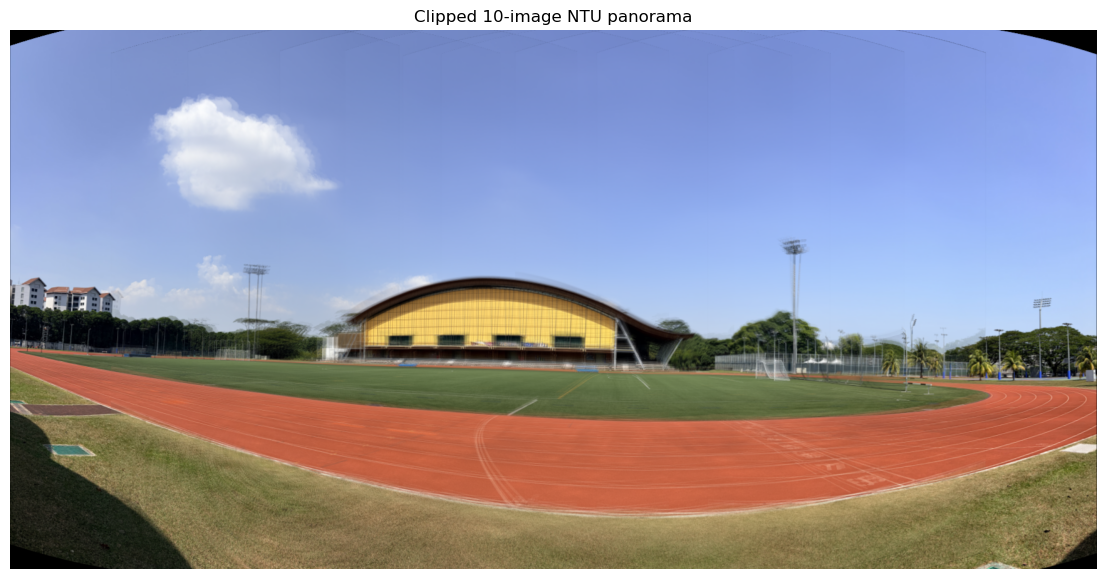

Saved: outputs/panorama_10_images.jpg
Panorama shape: (861, 1735, 3)


In [10]:
def canvas_geometry(images, transforms):
    corners = []
    for image, H in zip(images, transforms):
        h, w = image.shape[:2]
        box = np.float32([[[0, 0]], [[w, 0]], [[w, h]], [[0, h]]])
        corners.append(cv2.perspectiveTransform(box, H).reshape(-1, 2))
    corners = np.vstack(corners)

    minimum = np.floor(corners.min(axis=0)).astype(int)
    maximum = np.ceil(corners.max(axis=0)).astype(int)
    width, height = (maximum - minimum).tolist()
    translation = np.float32([[1.0, 0.0, -minimum[0]],
                              [0.0, 1.0, -minimum[1]],
                              [0.0, 0.0, 1.0]])
    return width, height, translation

def feather_weights(shape):
    mask = np.ones(shape, np.uint8)
    mask[[0, -1], :] = 0
    mask[:, [0, -1]] = 0
    distance = cv2.distanceTransform(mask, cv2.DIST_L2, 3)
    return np.clip(distance / (0.45 * min(shape)), 0, 1).astype(np.float32)

def clip_valid_rectangle(panorama, weight_sum, coverage=0.995):
    """Largest well-filled axis-aligned band inside the blended region.

    Start from the bounding box of every blended pixel, then repeatedly drop
    whichever of the four borders carries the largest share of invalid pixels,
    until at least `coverage` of the rectangle is covered. A summed-area table
    makes each candidate test O(1) instead of a full rescan.
    """
    valid = (weight_sum > 1e-6).astype(np.int64)
    rows = np.flatnonzero(valid.any(axis=1))
    cols_ = np.flatnonzero(valid.any(axis=0))
    top, bottom = int(rows[0]), int(rows[-1]) + 1
    left, right = int(cols_[0]), int(cols_[-1]) + 1

    area_sum = np.pad(valid.cumsum(0).cumsum(1), ((1, 0), (1, 0)))
    def covered(y0, y1, x0, x1):
        return int(area_sum[y1, x1] - area_sum[y0, x1]
                   - area_sum[y1, x0] + area_sum[y0, x0])

    while bottom - top > 1 and right - left > 1:
        area = (bottom - top) * (right - left)
        if covered(top, bottom, left, right) >= coverage * area:
            break
        borders = {
            "top": 1 - covered(top, top + 1, left, right) / (right - left),
            "bottom": 1 - covered(bottom - 1, bottom, left, right) / (right - left),
            "left": 1 - covered(top, bottom, left, left + 1) / (bottom - top),
            "right": 1 - covered(top, bottom, right - 1, right) / (bottom - top),
        }
        worst = max(borders, key=borders.get)
        top += worst == "top"
        bottom -= worst == "bottom"
        left += worst == "left"
        right -= worst == "right"

    return panorama[top:bottom, left:right]

def stitch_panorama(images, valid_masks, transforms):
    width, height, translation = canvas_geometry(images, transforms)
    color_sum = np.zeros((height, width, 3), np.float32)
    weight_sum = np.zeros((height, width), np.float32)

    for image, valid, H in zip(images, valid_masks, transforms):
        matrix = translation @ H
        source_weight = feather_weights(image.shape[:2]) * (valid > 0)
        warped_image = cv2.warpPerspective(image.astype(np.float32), matrix,
                                           (width, height))
        warped_weight = cv2.warpPerspective(source_weight, matrix, (width, height))
        color_sum += warped_image * warped_weight[..., None]
        weight_sum += warped_weight

    panorama = np.divide(color_sum, weight_sum[..., None],
                         out=np.zeros_like(color_sum),
                         where=weight_sum[..., None] > 1e-6)
    panorama = np.clip(panorama, 0, 255).astype(np.uint8)
    return clip_valid_rectangle(panorama, weight_sum)

panorama = stitch_panorama(images, valid_masks, transforms)
Image.fromarray(panorama).save(OUTPUT_DIR / "panorama_10_images.jpg", quality=94)

plt.figure(figsize=(16, 7))
plt.imshow(panorama)
plt.title("Clipped 10-image NTU panorama")
plt.axis("off")
plt.show()
print("Saved:", OUTPUT_DIR / "panorama_10_images.jpg")
print("Panorama shape:", panorama.shape)

canvas          1789 x 917 px, 93.91% of it filled
after clipping  1735 x 861 px, 91.06% of the canvas kept, 96.97% of the filled pixels kept
pixels covered by 2+ images: 79.64%; maximum overlap depth 6

 coverage      rectangle  invalid inside  filled pixels kept
    0.980     1735 x 905          1.996%              99.89%
    0.990     1735 x 885          0.981%              98.69%
    0.995     1735 x 861          0.498%              96.48%
    0.999     1735 x 823          0.097%              92.60%
    1.000     1734 x 785          0.000%              88.36%

photometric disagreement inside overlaps (grey levels): median 5.96, 90th pct 19.40, 99th pct 51.55, max 111.6
  on the strongest 5% of edges: median 18.66 (3.1x the overall median) - misalignment shows up where the gradient is steep

feather ramp reaches full weight on only 1.6% of a frame; median weight along the curved cylindrical border is 0.08
cylindrical border pixels: outermost valid ring mean grey 129.7 vs 134.5 one p

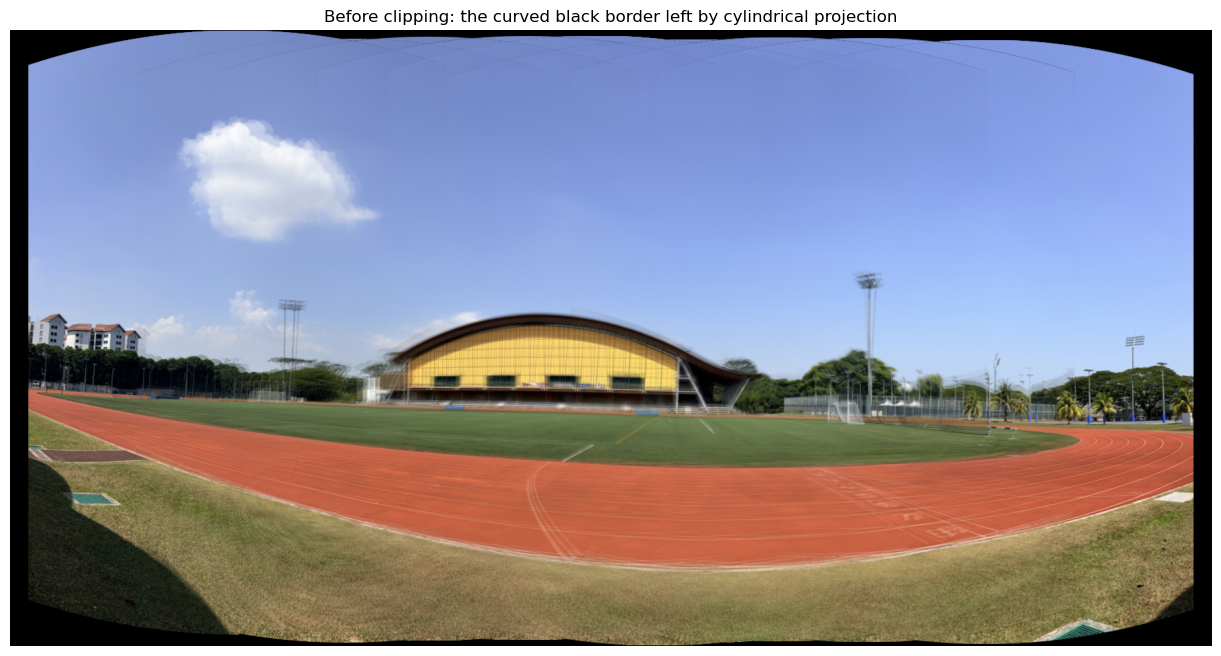

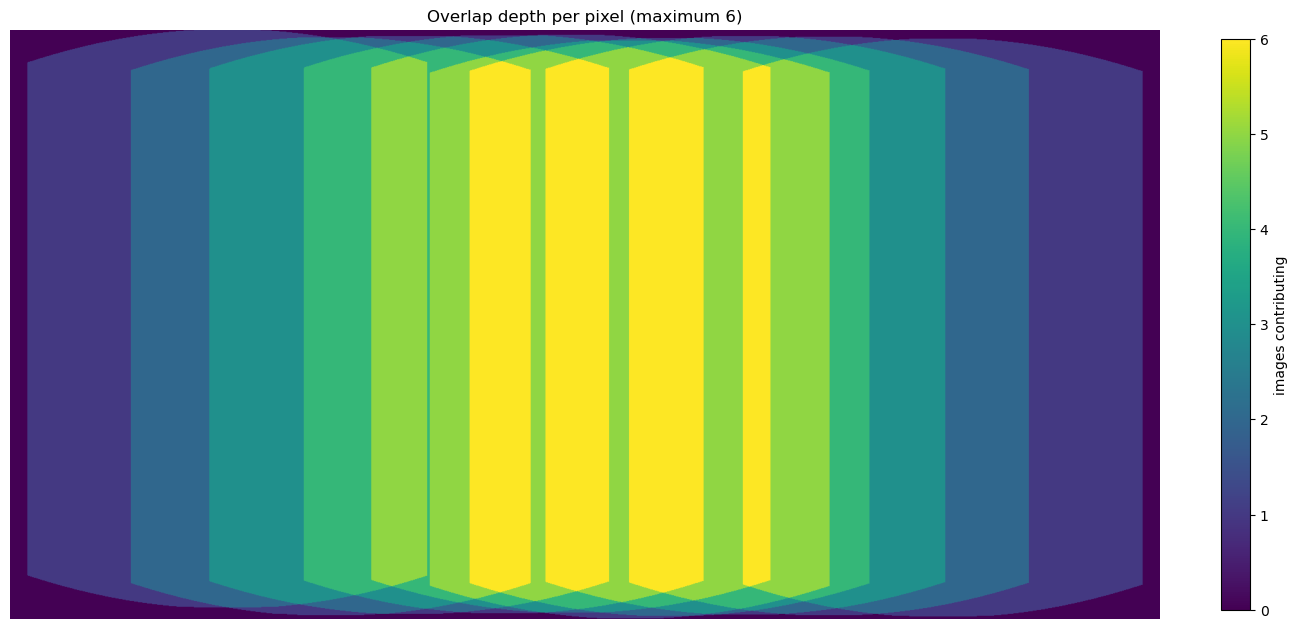

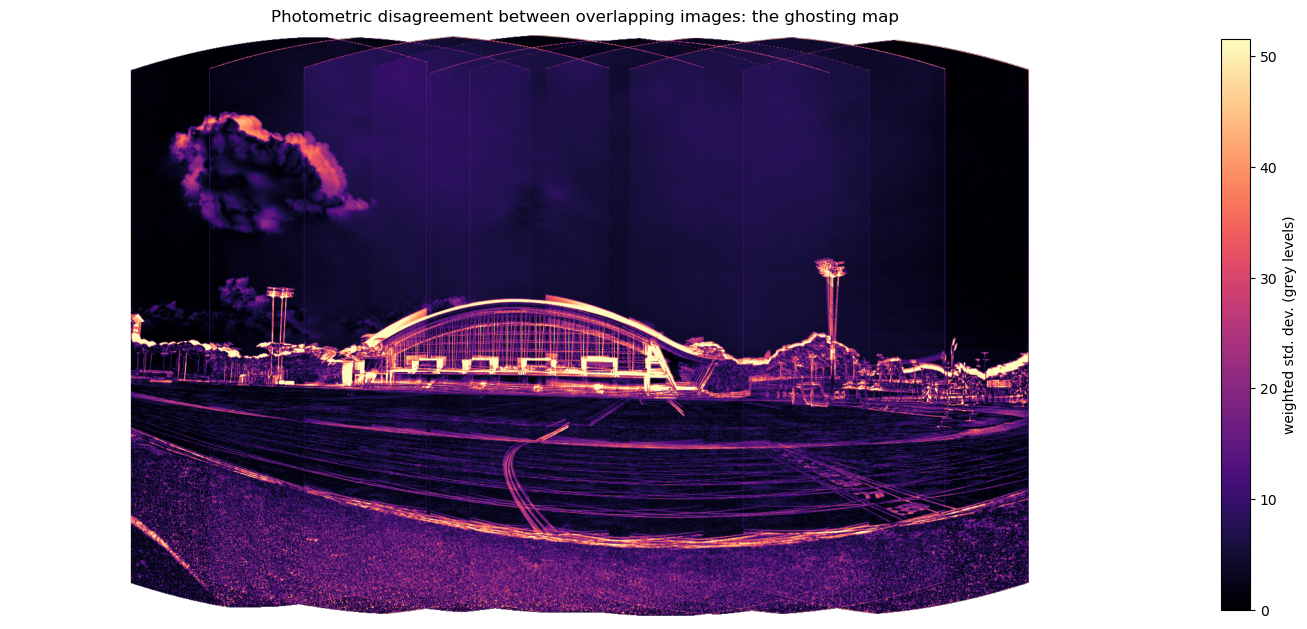

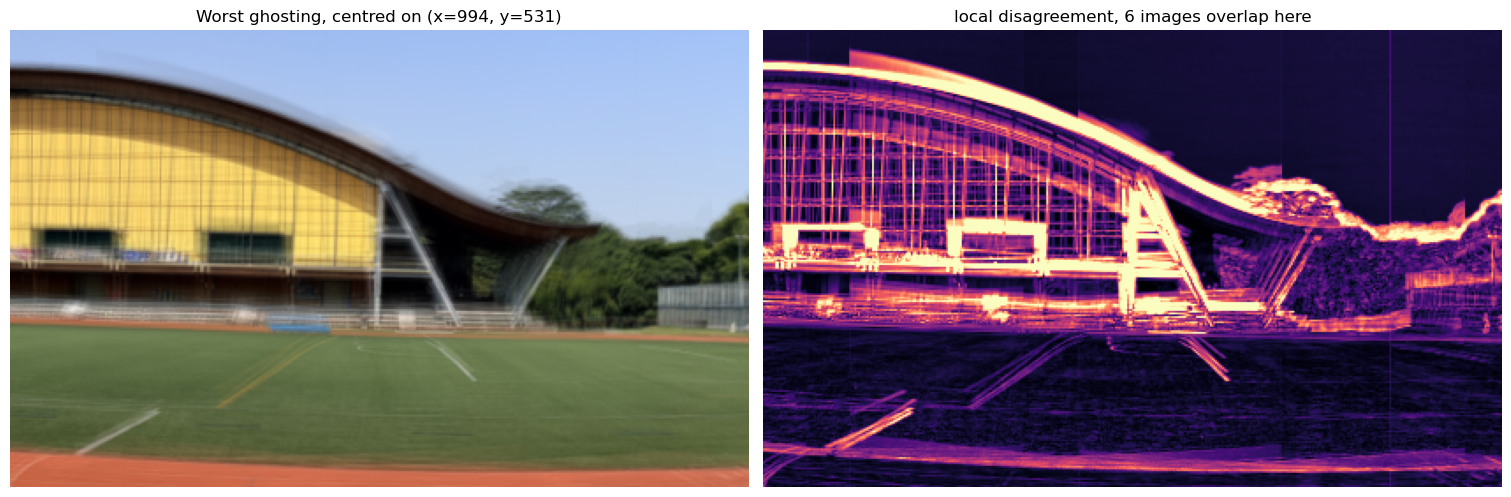

In [11]:
# --- Question C3 follow-up: what was cropped, and where does ghosting come from? ---
# Rebuild the accumulators so the unclipped canvas, the per-pixel image count and a
# weighted variance (the direct signature of ghosting) can all be inspected.
width, height, translation = canvas_geometry(images, transforms)
color_sum = np.zeros((height, width, 3), np.float32)
weight_sum = np.zeros((height, width), np.float32)
gray_sum = np.zeros((height, width), np.float32)
square_sum = np.zeros((height, width), np.float32)
overlap_count = np.zeros((height, width), np.int32)

for image, valid, H in zip(images, valid_masks, transforms):
    placement = translation @ H
    source_weight = feather_weights(image.shape[:2]) * (valid > 0)
    warped_image = cv2.warpPerspective(image.astype(np.float32), placement, (width, height))
    warped_weight = cv2.warpPerspective(source_weight, placement, (width, height))
    warped_gray = warped_image.mean(axis=2)
    color_sum += warped_image * warped_weight[..., None]
    weight_sum += warped_weight
    gray_sum += warped_gray * warped_weight
    square_sum += warped_gray ** 2 * warped_weight
    overlap_count += (warped_weight > 1e-3).astype(np.int32)

unclipped = np.clip(np.divide(color_sum, weight_sum[..., None],
                              out=np.zeros_like(color_sum),
                              where=weight_sum[..., None] > 1e-6), 0, 255).astype(np.uint8)
filled = weight_sum > 1e-6
clipped = clip_valid_rectangle(unclipped, weight_sum)

print(f"canvas          {unclipped.shape[1]} x {unclipped.shape[0]} px, "
      f"{filled.mean():.2%} of it filled")
print(f"after clipping  {clipped.shape[1]} x {clipped.shape[0]} px, "
      f"{clipped.size / unclipped.size:.2%} of the canvas kept, "
      f"{clipped.shape[0] * clipped.shape[1] / filled.sum():.2%} of the filled pixels kept")
print(f"pixels covered by 2+ images: {(overlap_count[filled] >= 2).mean():.2%}; "
      f"maximum overlap depth {overlap_count.max()}")

# clip_valid_rectangle only slices, so running it on the validity mask itself reports
# exactly how much black each coverage setting leaves behind.
print(f"\n{'coverage':>9s} {'rectangle':>14s} {'invalid inside':>15s} {'filled pixels kept':>19s}")
for setting in (0.98, 0.99, 0.995, 0.999, 1.0):
    band = clip_valid_rectangle(filled.astype(np.uint8), weight_sum, setting)
    print(f"{setting:9.3f} {f'{band.shape[1]} x {band.shape[0]}':>14s} "
          f"{1 - band.mean():15.3%} {band.sum() / filled.sum():19.2%}")

mean_gray = np.divide(gray_sum, weight_sum, out=np.zeros_like(gray_sum), where=filled)
variance = np.divide(square_sum, weight_sum, out=np.zeros_like(gray_sum), where=filled) - mean_gray ** 2
disagreement = np.sqrt(np.clip(variance, 0, None))
seam_zone = filled & (overlap_count >= 2)
print(f"\nphotometric disagreement inside overlaps (grey levels): "
      f"median {np.median(disagreement[seam_zone]):.2f}, "
      f"90th pct {np.percentile(disagreement[seam_zone], 90):.2f}, "
      f"99th pct {np.percentile(disagreement[seam_zone], 99):.2f}, "
      f"max {disagreement[seam_zone].max():.1f}")
edges = cv2.Sobel(cv2.GaussianBlur(mean_gray, (0, 0), 1.5), cv2.CV_32F, 1, 0, ksize=3)
strong_edge = seam_zone & (np.abs(edges) > np.percentile(np.abs(edges[seam_zone]), 95))
print(f"  on the strongest 5% of edges: median {np.median(disagreement[strong_edge]):.2f} "
      f"({np.median(disagreement[strong_edge]) / np.median(disagreement[seam_zone]):.1f}x the "
      f"overall median) - misalignment shows up where the gradient is steep")

# Two blending details worth checking rather than assuming.
ramp = feather_weights(images[0].shape[:2])
mask = (valid_masks[test_index] > 0).astype(np.uint8)
inner = cv2.erode(mask, np.ones((3, 3), np.uint8))
rim = (mask > 0) & (inner == 0)
ring = (inner > 0) & (cv2.erode(mask, np.ones((5, 5), np.uint8)) == 0)
sample = images[test_index].mean(axis=2)
print(f"\nfeather ramp reaches full weight on only {(ramp >= 1).mean():.1%} of a frame; "
      f"median weight along the curved cylindrical border is {np.median(ramp[rim]):.2f}")
print(f"cylindrical border pixels: outermost valid ring mean grey {sample[rim].mean():.1f} "
      f"vs {sample[ring].mean():.1f} one pixel further in - the image is remapped with "
      f"INTER_LINEAR (mixing in the black border) while the mask uses INTER_NEAREST, so "
      f"{(sample[rim] < 0.5 * sample[ring].mean()).mean():.1%} of that ring is more than "
      f"half darkened and survives as a hairline seam")

plt.figure(figsize=(16, 8))
plt.imshow(unclipped)
plt.title("Before clipping: the curved black border left by cylindrical projection")
plt.axis("off"); plt.show()

plt.figure(figsize=(16, 8))
plt.imshow(overlap_count, cmap="viridis")
plt.colorbar(fraction=0.023, label="images contributing")
plt.title(f"Overlap depth per pixel (maximum {overlap_count.max()})")
plt.axis("off"); plt.show()

plt.figure(figsize=(16, 8))
plt.imshow(np.where(seam_zone, disagreement, np.nan), cmap="magma",
           vmin=0, vmax=np.percentile(disagreement[seam_zone], 99))
plt.colorbar(fraction=0.023, label="weighted std. dev. (grey levels)")
plt.title("Photometric disagreement between overlapping images: the ghosting map")
plt.axis("off"); plt.show()

# Zoom on the worst offender, located automatically rather than picked by eye.
focus = cv2.boxFilter(np.where(seam_zone, disagreement, 0).astype(np.float32), -1, (61, 61))
cy, cx = np.unravel_index(int(np.argmax(focus)), focus.shape)
half_x, half_y = 210, 130
x0, x1 = max(cx - half_x, 0), min(cx + half_x, width)
y0, y1 = max(cy - half_y, 0), min(cy + half_y, height)
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
axes[0].imshow(unclipped[y0:y1, x0:x1])
axes[0].set_title(f"Worst ghosting, centred on (x={cx}, y={cy})")
axes[1].imshow(disagreement[y0:y1, x0:x1], cmap="magma",
               vmin=0, vmax=np.percentile(disagreement[seam_zone], 99))
axes[1].set_title(f"local disagreement, {overlap_count[cy, cx]} images overlap here")
for ax in axes:
    ax.axis("off")
plt.show()

#### Answer C3

**What was completed.** The canvas geometry is the bounding box of every transformed frame corner, plus the shift that moves it to non-negative coordinates:

```python
width, height = (maximum - minimum).tolist()
translation = np.float32([[1.0, 0.0, -minimum[0]],
                          [0.0, 1.0, -minimum[1]],
                          [0.0, 0.0, 1.0]])
```

(`.tolist()` matters: `cv2.warpPerspective` wants Python ints for its `dsize`, not NumPy scalars.)

`clip_valid_rectangle` starts from the bounding box of every blended pixel and then repeatedly deletes whichever of the four borders carries the largest *fraction* of invalid pixels, stopping once the rectangle is at least `coverage` filled. Greedily removing the worst edge is the standard approach to the largest-inscribed-rectangle problem, and a summed-area table over the validity mask makes each candidate test $O(1)$, so the loop costs one integral image plus a few hundred constant-time probes instead of rescanning a 1.6-megapixel canvas at every step.

**Results.**

| | value |
|---|---|
| canvas | 1789 × 917 px, **93.91%** of it filled |
| after clipping (`coverage = 0.995`) | **1735 × 861 px** — 91.06% of the canvas, **96.97% of the filled pixels** |
| pixels covered by 2+ images | **79.64%**; maximum overlap depth **6** |
| saved | `outputs/panorama_10_images.jpg`, 1735 × 861 |

**How much the coverage setting costs.** Because `clip_valid_rectangle` only slices, running it on the validity mask itself reports exactly what each setting leaves behind:

| coverage | rectangle | invalid remaining inside | filled pixels kept |
|---|---|---|---|
| 0.980 | 1735 × 905 | 1.996% | 99.89% |
| 0.990 | 1735 × 885 | 0.981% | 98.69% |
| **0.995** | **1735 × 861** | **0.498%** | 96.48% |
| 0.999 | 1735 × 823 | 0.097% | 92.60% |
| 1.000 | 1734 × 785 | 0.000% | 88.36% |

The default trades about 6% of the height for a rectangle that is 99.5% clean; the small black wedges still visible in the top corners of the final figure are that remaining half percent. Demanding a *perfectly* clean rectangle costs another 76 rows — a further 9% of the height — which is why a small tolerance is the sensible default.

The revealing detail is that **the width is 1735 at every setting while the height moves by 120 px**: the clipping is doing essentially all of its work vertically. That is a direct consequence of the cylindrical mapping. `map_x` $= f\tan\theta + w/2$ merely redistributes columns, but `map_y` $= f\,c_y/\cos\theta + h/2$ diverges as $|\theta|$ grows, so the top and bottom boundaries of each warped frame bow strongly while the sides stay nearly straight. Stacking ten of those horizontally leaves a canvas that is scalloped along the top and bottom and almost flat at the ends.

---

**Why a well-matched panorama still ghosts.** The blend accumulates a weighted variance as well as a weighted mean, which measures directly how much the overlapping images disagree at each pixel:

| photometric disagreement inside overlaps | grey levels |
|---|---|
| median | 5.96 |
| 90th percentile | 19.40 |
| 99th percentile | 51.55 |
| maximum | 111.6 |
| **median on the strongest 5% of edges** | **18.66 — 3.1× the overall median** |

That last row is the diagnosis. Disagreement is concentrated on high-gradient structure and nearly absent from flat regions, which is the signature of **geometric misalignment** rather than a global photometric error: on a steep edge, being wrong by a pixel produces a large intensity difference, while in a flat region the same misalignment produces none.

The automatically located worst window sits at $(x, y) = (994, 531)$, on the sports hall, where six frames overlap. Zoomed in, the roof arch appears as two or three offset copies, the vertical mullions smear into a haze, and the raking strut and the stand railings are visibly tripled — while the grass and sky in the very same crop are clean. Four causes, in order of contribution here:

1. **Parallax — the dominant one.** The model is one global translation per pair, which is exact only for a camera rotating about its optical centre. The source frames show the hall visibly growing across the sequence, so the photographer translated as well as turned. Under camera translation, image motion depends on **depth**: the near track edge and the distant hall move by different amounts, and no single $(dx, dy)$ can satisfy both. The median over inliers picks whichever depth the majority of features occupy, and everything at other depths ghosts. This is why the mid-distance hall smears while the foreground ground stays comparatively sharp. Note that RANSAC does not warn you about this — it happily reports 379–572 inliers, because a large subset at a *similar* depth genuinely does agree; the correspondences that would have exposed the problem are the ones it discards as outliers.
2. **Model error on top of that.** Reducing each homography to a median translation discards the 9.8–45.7 px of non-translational structure measured in C1, and the focal length $f = 0.95w$ is a guess. Both leave a residual that grows toward the frame edges.
3. **A scene that changed.** The cloud in the upper left glows in the disagreement map — it drifted between exposures. No geometric model can align a scene that moved.
4. **Photometric mismatch.** The sky in the disagreement map shows faint vertical rectangular bands aligned with frame boundaries: the phone re-metered between shots, so identical sky is a slightly different brightness in each frame. Feathering spreads that step over hundreds of pixels but cannot remove it — that needs gain compensation, which this pipeline does not have.

**Two blending details worth checking rather than assuming.** The feather ramp reaches full weight on only **1.6%** of a frame, because `feather_weights` normalises the distance transform by $0.45 \times \min(h, w) = 304$ px while the maximum possible distance from the border is 337 px. Almost every output pixel is therefore a weighted average of several frames. That is a very soft blend: it suppresses hard seams effectively, but it also spreads misalignment into a wide smear instead of concentrating it at a line — which is exactly the appearance of the ghosting above.

Separately, faint hairline curves are visible crossing the sky, and they have a specific cause. The image is remapped with `INTER_LINEAR`, which blends real pixels with the black `BORDER_CONSTANT` at the boundary, while the validity mask is remapped with `INTER_NEAREST`, which still labels those darkened pixels valid. Measured on image 5, the outermost "valid" ring has a mean grey of **129.7 against 134.5** one pixel further in, and **5.9%** of it is more than half darkened. Those darkened rings are carried into the blend with non-zero weight and survive as the hairlines. Eroding each validity mask by one pixel before use would remove them.

**What a production stitcher does differently**, and why each of these is exactly the fix for one row above: bundle-adjust all ten frames jointly instead of chaining (removes accumulated error), estimate per-image gains (removes the exposure bands), and choose a seam with a graph cut before multi-band blending (routes the boundary *around* misaligned and moving objects instead of averaging through them).

## Submission checklist

Submit the completed student notebook with visible outputs and `outputs/panorama_10_images.jpg`.

- Harris response and 150-corner overlay
- transformation comparison
- SIFT statistics and transformed-image matches
- nine adjacent-pair diagnostic rows and one inlier visualization
- clipped final panorama
- concise written answers

### Exit questions

1. Why does an edge have a weaker Harris response than a junction?
2. Why is Harris not intrinsically scale invariant?
3. What different problems are solved by Lowe's ratio test and RANSAC?
4. Why does cylindrical projection reduce panorama stretching?
5. Why can a well-matched panorama still contain ghosting?

#### Answers to the exit questions

**1. Why does an edge have a weaker Harris response than a junction?**

Because $M = G_\sigma * \begin{bmatrix} I_x^2 & I_xI_y \\ I_xI_y & I_y^2\end{bmatrix}$ summarises the *distribution* of gradient directions in a neighbourhood, and its eigenvalues $\lambda_1 \ge \lambda_2$ measure how much gradient energy lies along each of the two principal directions. On a straight edge every gradient in the window points the same way, so the distribution is one-dimensional: $\lambda_1$ is large and $\lambda_2 \approx 0$. Then $\det(M) = \lambda_1\lambda_2 \approx 0$ while $\mathrm{trace}(M) = \lambda_1 + \lambda_2$ is large, so $R \approx -k\lambda_1^2$ — large and **negative**. At a junction the window contains gradients in two independent directions, both eigenvalues are large, the determinant is large, and $R$ is strongly positive.

The intuition is the aperture problem. Viewed through a small window, an edge can slide along itself with no change in appearance, so its position is constrained in only one direction; a junction is pinned in both. $R$ is a cheap score for "constrained in both directions" that avoids an eigendecomposition per pixel — and that property is precisely what makes a feature *matchable*, which is why it is the right thing to detect. In this lab's response map the effect is plain: the mullion/transom crossings on the facade and the junctions where lane lines meet the painted lane numbers are bright, while the long roof edge and the plain stretches of lane line are dark or negative despite having just as much contrast.

**2. Why is Harris not intrinsically scale invariant?**

Because both of its scales are hard-coded constants rather than free parameters: a differentiation scale fixed by the $3\times3$ Sobel at about 1 px, and an integration scale fixed by the $\sigma = 1.5$ Gaussian at about 5–9 px. Together they ask one fixed question — *within roughly eight pixels, does the gradient point in two independent directions?* — and the answer depends on the size of the structure **in pixels**, which is exactly what rescaling changes. Shrink the image and a corner whose two edges met over 8 px now meets over 4; the Gaussian merges them into a single blurred edge, $M$ becomes effectively rank-one, $\det(M)$ collapses and $R$ drops below threshold. Enlarge it and the two edges separate beyond the window, so locally the operator sees only a straight edge. Meanwhile texture that was too fine to register aliases into new spurious responses. Nothing in $R = \det(M) - k\,\mathrm{trace}(M)^2$ adapts to any of it.

A2 measured this directly: repeatability falls monotonically from 83.33% at 95% scale to 30.67% at 50% scale, and by half scale only 62 pixels in the whole frame even clear the response threshold, against a full 150 at original size — the corners are not moving, they are ceasing to exist for this operator. Harris is also not scale-*covariant*, which is the deeper problem: it reports no size, so even a corner it does re-find carries no characteristic scale with which to normalise a descriptor patch. The fix is to search scale explicitly — compute the response over a pyramid of $\sigma$ and keep extrema in scale as well as in space (Harris–Laplace), which is what SIFT does with Difference-of-Gaussians. That is why B1's keypoints carry a `size` spanning 1.80 to 97.54 px.

**3. What different problems are solved by Lowe's ratio test and RANSAC?**

They remove different kinds of wrong match, in a specific order, and neither substitutes for the other.

**The ratio test is local and appearance-based.** It considers one query descriptor at a time and asks whether its best partner is distinctively better than its second best. It knows nothing about where anything is in the image. What it removes is **ambiguity**: features on repeated structure, and features whose true partner does not exist in the other image at all. Measured in B2, it lifted precision from 39.68% to 94.82%.

**RANSAC is global and geometric.** It takes the survivors, discards the descriptors entirely and keeps only coordinates, and asks which subset is simultaneously consistent with a *single* transform of the scene. What it removes is matches that are individually plausible in appearance but geometrically impossible given the others. In C1 it cut 491–629 ratio-test matches down to 379–572 inliers — so even after the ratio test, 8–29% were still geometrically wrong.

**The order is not arbitrary.** RANSAC's probability of drawing an all-inlier minimal sample falls exponentially with the outlier rate, so running it on the ~60% garbage that raw nearest-neighbour matching produces would need vastly more iterations or fail outright. The ratio test is a cheap filter that raises the inlier rate to where RANSAC becomes reliable. In the other direction, the ratio test cannot detect a match that is unambiguous but wrong — a distinctive-looking feature confidently matched to a similar-looking one elsewhere in the scene — and only geometry catches that. One is a test of *distinctiveness*, the other a test of *consistency*.

**4. Why does cylindrical projection reduce panorama stretching?**

Because it uses a surface that matches the camera's actual motion, whereas a plane does not. On a planar mosaic, frames from a rotating camera are related by homographies, and a homography corresponding to a rotation of $\theta$ magnifies detail near the frame edge by roughly $1/\cos^2\theta$. The stretch therefore grows without bound as the sweep widens — beyond about 60–90° the outer frames become unusable, and a full 360° panorama is impossible on a plane, since the projection would need infinite extent.

A camera rotating about a single vertical axis naturally parameterises the world by (azimuth, height). Projecting each frame onto a cylinder of radius $f$ and unrolling it makes azimuth a *linear* horizontal coordinate, so a pan of $\theta$ becomes a horizontal shift of $f\theta$ **regardless of how far the camera has already turned**. The tenth frame is treated exactly like the first, magnification is uniform along the strip, and the mosaic can wrap all the way round.

This lab exploits two direct consequences. The inter-frame transform collapses from 8 parameters to 2, which is why `match_adjacent` can reduce a homography to a median $(dx, dy)$ — a model so constrained that it cannot shear or stretch however noisy the estimate — and why chaining nine of them accumulates only ~1.2 px of error. The cost is the curved black border, because `map_y` $= f\,c_y/\cos\theta$ diverges at the horizontal extremes, which is exactly what `clip_valid_rectangle` exists to remove, and the fact that the assumed focal length ($f = 0.95w$, a guess) is now a systematic error the model cannot absorb, where a full homography would have partly compensated for it.

**5. Why can a well-matched panorama still contain ghosting?**

Because matching and blending answer different questions. RANSAC guarantees that a large set of correspondences is consistent with **the model you chose**; it says nothing about whether that model can describe the scene. All four failure modes are present and measurable in this panorama, whose overlaps disagree by a median of 5.96 grey levels and 18.66 on the strongest edges:

- **Parallax.** One translation per pair is exact only for rotation about the optical centre. The photographer also translated — the hall grows across the sequence — and under translation image motion depends on depth, so no single shift can align the near track and the distant building at once. This is the one that most looks like success: RANSAC reports hundreds of inliers because a large subset at one depth genuinely agrees, and the correspondences that would have revealed the conflict are rejected as outliers.
- **Model error.** Collapsing each homography to a translation discards the 9.8–45.7 px of measured non-translational structure, and the focal length is assumed rather than calibrated.
- **A scene that moved.** The cloud drifted between exposures and lights up the disagreement map. Geometry cannot align a scene that changed between frames.
- **Photometric mismatch.** Auto-exposure varied shot to shot, so even perfectly aligned pixels differ; visible as faint vertical bands in the sky.

Feathering makes all of this graceful rather than correct. Averaging two misaligned copies with a wide linear ramp turns a step into a smear — the roof arch becomes three faint arcs instead of one hard double edge — which is less objectionable but no more accurate. The real remedies attack the causes rather than the symptom: bundle adjustment over all frames jointly instead of a chain, per-image gain compensation, and seam finding (graph cut) followed by multi-band blending, which routes the boundary *around* the misaligned and moving objects rather than averaging through them.